# 02. Доступная история, структура программ и анализ данных

Основной вопрос: содержит ли история уже наблюдённых действий информацию о первом запуске нового задания? Все признаки строятся до начала текущей попытки. Индивидуальные истории участников validation/test разрешены как наблюдённый контекст, но их метки не используются для обучения параметров. Test не используется в разведочном анализе.

Ни один итоговый признак текущей попытки не является входом. Предметные признаки следующего задания извлекаются из условия и доступных блоков, без эталонного решения. MiniCode разбирается по [официальной грамматике](https://github.com/adaptive-learning/adaptive-learning-research/tree/master/data/robomission-2019-02-09).

In [1]:
from pathlib import Path
import json
import hashlib


def verify_frozen_training_source(root: Path) -> None:
    """Verify frozen training code before reproducing the recorded evaluation."""
    boundary = root / "dataset/protocol/test_evaluation_boundary.json"
    if not boundary.exists():
        return
    frozen_sources = json.loads(
        (root / "dataset/protocol/frozen_training_sources.json").read_text()
    )
    for filename, expected in frozen_sources["notebooks"].items():
        notebook = json.loads((root / "notebooks" / filename).read_text())
        source = "\n\n".join(
            "".join(cell["source"])
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
        )
        observed = hashlib.sha256(source.encode()).hexdigest()
        assert (
            observed == expected
        ), "Training source changed after the test was opened."


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown


def resolve_project_root(start: Path) -> Path:
    """Find the repository from its root or any notebook subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "dataset/raw").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Start Jupyter from the GraphProg repository or its notebooks directory."
    )


ROOT = resolve_project_root(Path.cwd())
for relative in (
    "dataset/processed",
    "dataset/protocol",
    "artifacts/runtime",
    "figures/generated",
):
    (ROOT / relative).mkdir(parents=True, exist_ok=True)

SEED = 20260923
rng = np.random.default_rng(SEED)
font_names = {font.name for font in font_manager.fontManager.ttflist}
assert "Times New Roman" in font_names
FONT = "Times New Roman"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
mpl.rcParams.update(
    {
        "font.family": FONT,
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 350,
        "savefig.dpi": 350,
        "axes.unicode_minus": True,
        "mathtext.fontset": "stix",
    }
)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


def table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Display a complete DataFrame using Jupyter's default table styling."""
    frame.to_csv(ROOT / "artifacts" / f"{name}.csv", index=False)
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.max_colwidth",
        None,
        "display.width",
        None,
    ):
        display(Markdown(caption))
        display(frame.reset_index(drop=True).round(3))


def save_figure(fig: mpl.figure.Figure, name: str) -> None:
    """Save at 350 dpi after checking the font contract on visible text."""
    from matplotlib.text import Text

    fig.canvas.draw()
    for text in fig.findobj(match=Text):
        if text.get_visible() and text.get_text():
            assert 18 <= text.get_fontsize() <= 20
            assert text.get_fontfamily() == ["Times New Roman"]
    fig.savefig(ROOT / "figures/generated" / f"{name}.png", dpi=FIGURE_DPI)
    fig.savefig(ROOT / "figures/generated" / f"{name}.pdf", dpi=FIGURE_DPI)


import ast
import re
from collections import Counter
from scipy.stats import spearmanr, ks_2samp
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

protocol = json.loads(
    (ROOT / "dataset/protocol/robomission_protocol.json").read_text()
)
verify_frozen_training_source(ROOT)
verify_frozen_training_source(ROOT)
assert (
    not protocol["locked_test_opened"]
    or (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists()
    or (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists()
)
students = pd.read_csv(ROOT / "dataset/protocol/robomission_split.csv")
events = pd.read_pickle(ROOT / "dataset/processed/robo_events.pkl")
attempts = pd.read_pickle(ROOT / "dataset/processed/robo_attempts.pkl")
problems = pd.read_pickle(
    ROOT / "dataset/processed/robo_problems.pkl"
).set_index("id")
cohorts = {
    part: pd.read_pickle(ROOT / f"dataset/processed/robo_cohort_{part}.pkl")
    for part in ["train", "validation", "locked_test"]
}
# Locked labels are carried unchanged into preparation artifacts, never summarized here.


## Разбор MiniCode

Граф содержит узлы команд и управляющих конструкций, связи вложенности и соседства. Число повторений и условие сохраняются в метке управляющего узла. Неполные или неизвестные записи получают резервное символьное представление и индикатор ошибки разбора; они не удаляются. Пустая программа допустима.

Детерминированные признаки структуры не подбираются по целевой метке. Для следующих моделей сохраняется сам граф, а не только число блоков.

In [2]:
NODE_TYPES = ["ROOT", "f", "l", "r", "s", "R", "W", "I", "ELSE", "UNKNOWN"]
TYPE_ID = {s: i for i, s in enumerate(NODE_TYPES)}


def parse_minicode(program: str) -> dict:
    """Parse command/control nesting and sibling order; preserve invalid code."""
    labels, parents, previous = ["ROOT"], [-1], [-1]
    position = 0

    def block(parent: int, expect_close: bool = False) -> None:
        nonlocal position
        prior = -1
        while position < len(program) and program[position] != "}":
            char = program[position]
            position += 1
            if char in "flrs":
                label = char
            elif char in "RWI/":
                start = position
                while position < len(program) and program[position] != "{":
                    if program[position] in "}":
                        raise ValueError("missing opening brace")
                    position += 1
                if position >= len(program):
                    raise ValueError("incomplete control")
                arg = program[start:position]
                if char == "R" and not re.fullmatch(r"\d+", arg):
                    raise ValueError("invalid repeat")
                if char in "WI" and not re.fullmatch(
                    r"!?[bgkdy]|x(?:!=|<=|>=|[<>=])\d+", arg
                ):
                    raise ValueError("invalid condition")
                if char == "/" and arg:
                    raise ValueError("invalid else")
                label = ("ELSE" if char == "/" else char) + (
                    ":" + arg if arg else ""
                )
            else:
                raise ValueError("unknown token")
            index = len(labels)
            labels.append(label)
            parents.append(parent)
            previous.append(prior)
            prior = index
            if char in "RWI/":
                position += 1
                block(index, expect_close=True)
        if expect_close:
            if position >= len(program) or program[position] != "}":
                raise ValueError("missing closing brace")
            position += 1

    try:
        block(0)
        if position != len(program):
            raise ValueError("unmatched brace")
        valid = True
    except ValueError:
        labels = ["ROOT"] + [("UNKNOWN:" + c) for c in program]
        parents = [-1] + [0] * len(program)
        previous = (
            [-1] + [-1] + list(range(1, len(program))) if program else [-1]
        )
        valid = False
    depths = [0]
    for parent in parents[1:]:
        depths.append(depths[parent] + 1)
    kinds = [label.split(":")[0] for label in labels]
    counts = Counter(kinds)
    features = {f"code_{kind}": counts[kind] for kind in NODE_TYPES[1:]}
    features.update(
        code_nodes=len(labels) - 1,
        code_depth=max(depths),
        code_length=len(program),
        code_depth_sum=sum(depths),
        code_invalid=int(not valid),
    )
    return {
        "types": [TYPE_ID[kind] for kind in kinds],
        "labels": labels,
        "parents": parents,
        "previous": previous,
        "features": features,
        "valid": valid,
    }


assert parse_minicode("R6{Ix>1{s}/{r}}")["valid"]
assert parse_minicode("W!b{Ik{f}Iy{r}Id{l}}")["valid"]
assert not parse_minicode("R3{f")["valid"]
assert (
    parse_minicode("fR3{l}")["features"]
    != parse_minicode("R3{fl}")["features"]
)
programs = sorted(set(attempts.program.fillna("")))
graphs = {p: parse_minicode(p) for p in programs}
program_ids = {p: i for i, p in enumerate(programs)}
(ROOT / "dataset/processed/program_graphs.json").write_text(
    json.dumps(
        {
            "programs": programs,
            "graphs": [graphs[p] for p in programs],
            "node_types": NODE_TYPES,
        }
    )
)
train_ids = set(students.loc[students.split.eq("train"), "student"])
train_programs = attempts.loc[
    attempts.student.isin(train_ids), "program"
].fillna("")
parse_summary = pd.DataFrame(
    [
        ["Исторические попытки train", len(train_programs)],
        ["Уникальные конечные программы train", train_programs.nunique()],
        [
            "Попытки с резервным представлением",
            sum(not graphs[p]["valid"] for p in train_programs),
        ],
        ["Пустые конечные программы", int(train_programs.eq("").sum())],
    ],
    columns=["Характеристика", "Число"],
)
table(
    parse_summary,
    "Таблица 8. Полнота структурного представления",
    "02_parse_coverage",
)


Таблица 8. Полнота структурного представления

,Характеристика,Число
0,Исторические попытки train,115649
1,Уникальные конечные программы train,6151
2,Попытки с резервным представлением,305
3,Пустые конечные программы,3162


Из 115 649 исторических попыток train резервное представление требуется для 305 программ. Они не исключаются из выборки. 3 162 пустых конечных программы являются отдельным наблюдаемым состоянием, а не успешно решённой задачей.

## Исторические эпизоды и наблюдаемая трудоёмкость

Ретроспективные исходы описываются по полным попыткам, но не используются как признаки текущего задания. Предикторы истории строятся отдельно по событиям, наблюдённым строго до начала прогнозируемого посещения. Уже наблюдённые префиксы продолжающихся прошлых попыток также включаются в контекст.

Для дополнительной задачи используется номер первого успешного запуска или число наблюдённых запусков при отсутствии успеха. Последний случай является правым цензурированием.

In [3]:
episode = attempts.set_index("id").copy()
end_times = events.groupby("attempt").timestamp.max()
episode["end"] = end_times
assert (episode.end >= episode.start).all()
run = (
    events[events.event_type.eq("execution")]
    .sort_values(["event_order"])
    .copy()
)
run["run_index"] = run.groupby("attempt").cumcount() + 1
first_success = run[run.correct.eq(1)].groupby("attempt").run_index.min()
first_label = run.drop_duplicates("attempt").set_index("attempt").correct
episode["first_correct"] = first_label.reindex(episode.index)
episode["first_observed"] = episode.first_correct.notna().astype(int)
episode["success_run"] = first_success.reindex(episode.index)
episode["event_observed"] = episode.success_run.notna().astype(int)
episode["duration_runs"] = episode.success_run.fillna(
    episode.n_executions
).astype(int)
episode["program"] = episode.program.fillna("")
episode["graph_id"] = episode.program.map(program_ids)
structure = pd.DataFrame(
    [graphs[p]["features"] for p in episode.program], index=episode.index
)
episode = episode.join(structure)
events["code_chars"] = events.program.str.len()
local_stats = events.groupby("attempt").code_chars.agg(
    ["mean", "std", "max", "min"]
)
local_stats.columns = [
    "local_code_mean",
    "local_code_std",
    "local_code_max",
    "local_code_min",
]
episode = episode.join(local_stats).fillna({"local_code_std": 0})
for col in ["time", "n_edits", "n_executions"]:
    episode["log_" + col] = np.log1p(episode[col])
assert (episode.duration_runs >= 0).all()
episode.to_pickle(ROOT / "dataset/processed/robo_episode_features.pkl")
train_ep = episode[episode.student.isin(train_ids)]
table(
    pd.DataFrame(
        [
            ["Наблюдался успешный запуск", int(train_ep.event_observed.sum())],
            [
                "Успех не наблюдался, были запуски",
                int(
                    (
                        (train_ep.event_observed == 0)
                        & (train_ep.n_executions > 0)
                    ).sum()
                ),
            ],
            ["Запусков не было", int(train_ep.n_executions.eq(0).sum())],
            [
                "Успех после первого запуска",
                int(train_ep.success_run.gt(1).sum()),
            ],
        ],
        columns=["Исход исторической попытки train", "Число"],
    ),
    "Таблица 9. Наблюдаемость дополнительной цели",
    "02_effort_observability",
)


Таблица 9. Наблюдаемость дополнительной цели

,Исход исторической попытки train,Число
0,Наблюдался успешный запуск,102530
1,"Успех не наблюдался, были запуски",11380
2,Запусков не было,1739
3,Успех после первого запуска,53633


Успех наблюдается в 102 530 исторических эпизодах; в 11 380 эпизодах запуски есть, но успех не зарегистрирован. Последние являются цензурированными для числа запусков до успеха. 1 739 эпизодов без запуска не следует приравнивать к первому неуспеху.

## Причинно доступное пространство входов

Термин «доступное» относится к времени измерения, а не к доказанному причинному эффекту. Для каждого нового задания строятся: его фиксированное описание; накопленная статистика ученика; статистика по доступным конструкциям; последние 32 наблюдённых префикса прошлых попыток для последовательных моделей. Граница истории проверяется для каждой строки.

В качестве признаков сложности задания нельзя использовать среднюю успешность всей выборки. Такие оценки будут обучаться только на training-fold. Длина истории 32 — заранее заданное вычислительное ограничение, которое необходимо учитывать при интерпретации.

## Наблюдаемость прошлых попыток в момент нового запроса

Может ли выбор «завершённых» попыток зависеть от будущих действий? Для каждой новой задачи сравнивается число уже начатых прошлых попыток с числом попыток, последний архивный event которых предшествует запросу. Если прежняя попытка продолжается после запроса, допустим только её уже наблюдённый префикс. Таблица описывает такие случаи; она не использует исход нового задания.

In [4]:
overlap_rows = []
for part in ["train", "validation"]:
    affected_queries, affected_students, maximum_active = 0, set(), 0
    for student, queries in cohorts[part].groupby("student", sort=False):
        learner_episodes = episode[episode.student.eq(student)]
        starts = np.sort(
            learner_episodes.start.astype("datetime64[ns, UTC]")
            .astype("int64")
            .to_numpy()
        )
        ends = np.sort(
            learner_episodes.end.astype("datetime64[ns, UTC]")
            .astype("int64")
            .to_numpy()
        )
        query_time = (
            queries.start.astype("datetime64[ns, UTC]")
            .astype("int64")
            .to_numpy()
        )
        begun = np.searchsorted(starts, query_time, side="left")
        ended = np.searchsorted(ends, query_time, side="left")
        active = begun - ended
        assert (active >= 0).all()
        affected_queries += int((active > 0).sum())
        maximum_active = max(maximum_active, int(active.max()))
        if (active > 0).any():
            affected_students.add(student)
    overlap_rows.append(
        {
            "Split": part.title(),
            "n": len(cohorts[part]),
            "Queries with continuing history": affected_queries,
            "Affected learners": len(affected_students),
            "Maximum concurrent prior attempts": maximum_active,
        }
    )
table(
    pd.DataFrame(overlap_rows),
    "Наблюдаемость контекста при продолжающихся прошлых попытках",
    "02_prefix_availability",
)


Наблюдаемость контекста при продолжающихся прошлых попытках

,Split,n,Queries with continuing history,Affected learners,Maximum concurrent prior attempts
0,Train,108877,8585,1336,12
1,Validation,23326,1850,310,8


Продолжающиеся прошлые попытки затрагивают 8 585 train- и 1 850 validation-запросов, то есть около 8% наблюдений. Полностью исключать такую попытку на основании её будущего последнего события нельзя. Используется наблюдённый к моменту запроса префикс; последующее обучение опирается на это правило.

## Причинные префиксы истории

На каждом временном срезе используются только события с timestamp строго меньше начала текущего задания. Включаются доступные префиксы прошлых попыток, даже если они будут продолжены позже. Итоговая программа, конечные счётчики и момент последнего события архива не используются для формирования истории. Текущая попытка исключена. Порядок последних 32 прошлых попыток определяется их последним уже наблюдённым действием.

In [5]:
def build_event_prefix_features(
    cohort: pd.DataFrame,
    attempt_starts: pd.DataFrame,
    event_data: pd.DataFrame,
    question_features: pd.DataFrame,
    partition: str,
    history_columns: list[str],
    sequence_columns: list[str],
    structure_columns: list[str],
    concept_names: list[str],
    max_history: int,
    catalog: dict,
) -> tuple[pd.DataFrame, dict]:
    """Build each forecast from events strictly earlier than its query timestamp.

    Attempt metadata is restricted to its identifier, learner, task and start.
    Final attempt outcomes, counters, programs and end times are never inputs.
    The mutable catalog caches a deterministic parser, not a learned embedding.
    """
    records, sequences = [], []
    attempt_groups = attempt_starts.groupby("student", sort=False)
    event_groups = event_data.groupby("student", sort=False)
    descriptor_cache = {}

    def describe_program(program: str) -> tuple[int, np.ndarray]:
        if program not in descriptor_cache:
            if program not in catalog["ids"]:
                catalog["ids"][program] = len(catalog["programs"])
                catalog["programs"].append(program)
                catalog["graphs"][program] = parse_minicode(program)
            description = catalog["graphs"][program]["features"]
            descriptor_cache[program] = (
                catalog["ids"][program],
                np.array(
                    [description[name] for name in structure_columns],
                    dtype=float,
                ),
            )
        return descriptor_cache[program]

    for student, queries in cohort.groupby("student", sort=False):
        metadata = (
            attempt_groups.get_group(student)
            if student in attempt_groups.indices
            else attempt_starts.iloc[:0]
        )
        metadata = metadata.sort_values(["start", "id"]).reset_index(drop=True)
        identifiers = metadata.id.to_numpy()
        locations = {
            attempt: index for index, attempt in enumerate(identifiers)
        }
        started_at = (
            metadata.start.astype("datetime64[ns, UTC]")
            .astype("int64")
            .to_numpy()
        )
        task = metadata.problem.to_numpy(dtype=int)
        size = len(metadata)
        last_observed_at = started_at.copy()
        last_program = [""] * size
        solved = np.zeros(size, dtype=float)
        first_correct = np.full(size, np.nan)
        edit_count, run_count, elapsed = (
            np.zeros(size),
            np.zeros(size),
            np.zeros(size),
        )
        code_count, code_sum, code_squared_sum = (
            np.zeros(size),
            np.zeros(size),
            np.zeros(size),
        )
        learner_events = (
            event_groups.get_group(student)
            if student in event_groups.indices
            else event_data.iloc[:0]
        )
        learner_events = learner_events.sort_values(["timestamp", "id"])
        event_times = (
            learner_events.timestamp.astype("datetime64[ns, UTC]")
            .astype("int64")
            .to_numpy()
        )
        event_values = learner_events[
            [
                "attempt",
                "event_type",
                "program",
                "correct",
                "time_from_attempt_start",
            ]
        ].itertuples(index=False, name=None)
        event_rows = list(event_values)
        cursor = 0
        for query in queries.sort_values(["start", "id"]).itertuples():
            cutoff = query.start.value
            while cursor < len(event_rows) and event_times[cursor] < cutoff:
                attempt, event_type, program, correct, time_value = event_rows[
                    cursor
                ]
                index = locations[attempt]
                assert started_at[index] <= event_times[cursor] < cutoff
                last_observed_at[index] = event_times[cursor]
                if isinstance(program, str):
                    last_program[index] = program
                    characters = len(program)
                    code_count[index] += 1
                    code_sum[index] += characters
                    code_squared_sum[index] += characters * characters
                if event_type == "edit":
                    edit_count[index] += 1
                elif event_type == "execution":
                    if run_count[index] == 0:
                        first_correct[index] = float(correct)
                    run_count[index] += 1
                    solved[index] = max(solved[index], float(correct))
                if pd.notna(time_value):
                    elapsed[index] = max(
                        elapsed[index], float(time_value), 0.0
                    )
                cursor += 1
            prior = np.flatnonzero(started_at < cutoff)
            assert query.id not in identifiers[prior]
            assert np.all(last_observed_at[prior] < cutoff)
            count = len(prior)
            record = {
                "id": query.id,
                "student": student,
                "problem": query.problem,
                "y": query.y,
                "fold": query.fold,
                "split": partition,
                "start": query.start,
                "history_n": count,
                "history_log_n": np.log1p(count),
                "history_last_gap": (
                    np.log1p((cutoff - last_observed_at[prior].max()) / 1e9)
                    if count
                    else 0.0
                ),
                "history_available": int(count > 0),
            }
            if count:
                code_mean = np.divide(
                    code_sum[prior],
                    code_count[prior],
                    out=np.full(count, np.nan),
                    where=code_count[prior] > 0,
                )
                centered = code_squared_sum[prior] - np.divide(
                    code_sum[prior] ** 2,
                    code_count[prior],
                    out=np.zeros(count),
                    where=code_count[prior] > 0,
                )
                variance = np.divide(
                    centered,
                    code_count[prior] - 1,
                    out=np.zeros(count),
                    where=code_count[prior] > 1,
                )
                code_std = np.sqrt(np.maximum(variance, 0))
                descriptors = [
                    describe_program(last_program[index]) for index in prior
                ]
                graph_ids = np.array([entry[0] for entry in descriptors])
                structure_values = np.stack(
                    [entry[1] for entry in descriptors]
                )
                local = np.column_stack(
                    [
                        np.log1p(elapsed[prior]),
                        np.log1p(edit_count[prior]),
                        np.log1p(run_count[prior]),
                        code_mean,
                        code_std,
                    ]
                )
                values = np.column_stack(
                    [
                        solved[prior],
                        first_correct[prior],
                        local,
                        structure_values,
                    ]
                )
                assert values.shape[1] == len(history_columns)
                valid = np.isfinite(values)
                means = np.divide(
                    np.where(valid, values, 0).sum(axis=0),
                    valid.sum(axis=0),
                    out=np.full(values.shape[1], np.nan),
                    where=valid.sum(axis=0) > 0,
                )
                skill = question_features.loc[
                    task[prior], ["q_" + name for name in concept_names]
                ].to_numpy()
                skill_counts = skill.sum(axis=0)
                skill_success = (skill * solved[prior, None]).sum(axis=0)
                ordering = np.lexsort(
                    (
                        identifiers[prior],
                        started_at[prior],
                        last_observed_at[prior],
                    )
                )[-max_history:]
                sequence = np.column_stack(
                    [
                        task[prior],
                        solved[prior],
                        first_correct[prior],
                        (run_count[prior] > 0).astype(int),
                        graph_ids,
                        local,
                        structure_values,
                    ]
                )
                assert sequence.shape[1] == len(sequence_columns)
                sequence = np.nan_to_num(sequence[ordering], nan=0.0).astype(
                    np.float32
                )
            else:
                means = np.full(len(history_columns), np.nan)
                skill_counts, skill_success = np.zeros(
                    len(concept_names)
                ), np.zeros(len(concept_names))
                sequence = np.empty(
                    (0, len(sequence_columns)), dtype=np.float32
                )
            for name, value in zip(history_columns, means):
                record["hist_" + name] = value
            for index, name in enumerate(concept_names):
                record["skill_" + name + "_n"] = np.log1p(skill_counts[index])
                record["skill_" + name + "_rate"] = (
                    skill_success[index] + 1
                ) / (skill_counts[index] + 2)
            record.update(question_features.loc[query.problem].to_dict())
            records.append(record)
            sequences.append(sequence)
    frame = pd.DataFrame(records)
    assert frame.id.is_unique and set(frame.id) == set(cohort.id)
    frame.attrs["feature_revision"] = "event_prefix_v2"
    return frame, {
        "ids": frame.id.to_numpy(),
        "sequences": sequences,
        "columns": sequence_columns,
        "feature_revision": "event_prefix_v2",
    }


In [6]:
CONCEPTS = ["repeat", "while", "if", "if-else", "position", "shoot"]
qrows = []
for qid, row in problems.iterrows():
    statement = ast.literal_eval(row.statement)
    fields = statement["fields"]
    q = {
        "problem": int(qid),
        "q_level": row.level1,
        "q_sublevel": row.level2,
        "q_rows": len(fields.split(";")),
        "q_cols": len(fields.split(";")[0].split("|")),
        "q_diamonds": fields.count("D"),
        "q_asteroids": fields.count("A"),
        "q_meteoroids": fields.count("M"),
        "q_limit": statement.get("length", np.nan),
    }
    for concept in CONCEPTS:
        q["q_" + concept] = int(concept in statement["toolbox"])
    qrows.append(q)
qfeatures = pd.DataFrame(qrows).set_index("problem")
qfeatures.to_pickle(ROOT / "dataset/processed/robo_problem_features.pkl")
STRUCTURE = list(structure.columns)
LOCAL = [
    "log_time",
    "log_n_edits",
    "log_n_executions",
    "local_code_mean",
    "local_code_std",
]
HISTORY_VALUES = ["solved", "first_correct"] + LOCAL + STRUCTURE
sequence_cols = (
    ["problem", "solved", "first_correct", "first_observed", "graph_id"]
    + LOCAL
    + STRUCTURE
)
MAX_HISTORY = 32
catalog = {"programs": programs, "graphs": graphs, "ids": program_ids}
attempt_starts = attempts[["id", "student", "problem", "start"]].copy()
all_sequences, frames = {}, {}
for part, cohort in cohorts.items():
    frame, sequences = build_event_prefix_features(
        cohort,
        attempt_starts,
        events,
        qfeatures,
        part,
        HISTORY_VALUES,
        sequence_cols,
        STRUCTURE,
        CONCEPTS,
        MAX_HISTORY,
        catalog,
    )
    # Future outcomes are supervised targets only, kept outside the feature list.
    frame["effort_runs"] = frame.id.map(episode.duration_runs).astype(int)
    frame["effort_observed"] = frame.id.map(episode.event_observed).astype(int)
    frame.to_pickle(ROOT / f"dataset/processed/robo_features_{part}.pkl")
    import pickle

    with (ROOT / f"dataset/processed/robo_sequences_{part}.pkl").open(
        "wb"
    ) as handle:
        pickle.dump(sequences, handle)
    frames[part], all_sequences[part] = frame, sequences
(ROOT / "dataset/processed/program_graphs.json").write_text(
    json.dumps(
        {
            "programs": programs,
            "graphs": [graphs[program] for program in programs],
            "node_types": NODE_TYPES,
        }
    )
)
excluded = {
    "id",
    "student",
    "y",
    "fold",
    "split",
    "start",
    "effort_runs",
    "effort_observed",
}
feature_names = [
    column for column in frames["train"].columns if column not in excluded
]
(ROOT / "dataset/protocol/robo_feature_contract.json").write_text(
    json.dumps(
        {
            "feature_revision": "event_prefix_v2",
            "availability_rule": "Observed events strictly before query start; no finalization oracle",
            "features": feature_names,
            "structure": ["hist_" + column for column in STRUCTURE],
            "local": ["hist_" + column for column in LOCAL],
            "max_history": MAX_HISTORY,
            "concepts": CONCEPTS,
            "sequence_columns": sequence_cols,
            "categorical": ["problem"],
            "forbidden": sorted(excluded),
        },
        indent=2,
    )
)
tr, va = frames["train"], frames["validation"]
table(
    pd.DataFrame(
        [
            [
                "Train",
                len(tr),
                tr.student.nunique(),
                int(tr.history_n.eq(0).sum()),
                tr.history_n.median(),
            ],
            [
                "Validation",
                len(va),
                va.student.nunique(),
                int(va.history_n.eq(0).sum()),
                va.history_n.median(),
            ],
        ],
        columns=[
            "Выборка",
            "Наблюдения",
            "Учащиеся",
            "Без истории",
            "Медиана истории",
        ],
    ),
    "Доступность контекста из наблюдённых префиксов",
    "02_history_coverage",
)


Доступность контекста из наблюдённых префиксов

,Выборка,Наблюдения,Учащиеся,Без истории,Медиана истории
0,Train,108877,8075,8043,8.0
1,Validation,23326,1750,1745,8.0


Медиана доступного опыта равна восьми прошлым попыткам в обеих выборках. Истории нет для 8 043 train- и 1 745 validation-запросов; поэтому отсутствие контекста сохраняется как отдельный режим, а не заменяется фиктивным опытом.

Следующая молчаливая проверка удаляет будущие события и подтверждает неизменность уже доступных признаков, включая случаи продолжающихся прошлых попыток.

In [7]:
# Future observations must not alter already available predictor values.
probe_queries = cohorts["train"].iloc[
    np.linspace(0, len(cohorts["train"]) - 1, 8).astype(int)
]
# Add continuing-history cases, where a finalization oracle would be detectable.
overlap_probe_ids = []
for learner, queries in cohorts["train"].groupby("student", sort=False):
    past = episode[episode.student.eq(learner)]
    for query_row in queries.itertuples():
        if (
            (past.start < query_row.start) & (past.end >= query_row.start)
        ).any():
            overlap_probe_ids.append(query_row.id)
            break
    if len(overlap_probe_ids) == 4:
        break
probe_queries = pd.concat(
    [
        probe_queries,
        cohorts["train"][cohorts["train"].id.isin(overlap_probe_ids)],
    ]
).drop_duplicates("id")
comparison_columns = [
    name
    for name in frames["train"].columns
    if name not in ["effort_runs", "effort_observed"]
]
for probe in probe_queries.itertuples():
    query = cohorts["train"][cohorts["train"].id.eq(probe.id)]
    learner_starts = attempt_starts[attempt_starts.student.eq(probe.student)]
    learner_events = events[events.student.eq(probe.student)]
    full_frame, full_sequence = build_event_prefix_features(
        query,
        learner_starts,
        learner_events,
        qfeatures,
        "train",
        HISTORY_VALUES,
        sequence_cols,
        STRUCTURE,
        CONCEPTS,
        MAX_HISTORY,
        catalog,
    )
    observed_frame, observed_sequence = build_event_prefix_features(
        query,
        learner_starts[learner_starts.start < probe.start],
        learner_events[learner_events.timestamp < probe.start],
        qfeatures,
        "train",
        HISTORY_VALUES,
        sequence_cols,
        STRUCTURE,
        CONCEPTS,
        MAX_HISTORY,
        catalog,
    )
    pd.testing.assert_frame_equal(full_frame, observed_frame)
    np.testing.assert_allclose(
        full_sequence["sequences"][0],
        observed_sequence["sequences"][0],
        equal_nan=True,
    )
    saved = (
        frames["train"]
        .loc[frames["train"].id.eq(probe.id), comparison_columns]
        .reset_index(drop=True)
    )
    pd.testing.assert_frame_equal(
        full_frame[comparison_columns], saved, check_dtype=False
    )

revision = json.loads(
    (ROOT / "dataset/protocol/feature_revision.json").read_text()
)
revision.update(
    {
        "status": "prefix_invariance_verified",
        "invariance_probes": len(probe_queries),
        "overlap_probes": len(overlap_probe_ids),
    }
)
(ROOT / "dataset/protocol/feature_revision.json").write_text(
    json.dumps(revision, indent=2)
);


## Описательная статистика доступных предикторов

Каковы масштаб, вариабельность и хвосты распределений до обучения модели? Ниже сводка train. Историческая успешность не вычисляется для учащихся без наблюдённых запусков: это отсутствие информации, а не нулевая успешность. Широкая сводка всех признаков сохраняется отдельно; видимая таблица охватывает шесть содержательных измерений.

Обозначения в сводке и последующих матрицах: **History** — ln(1 + число прошлых попыток); **First success** — доля первых успешных запусков среди прошлых попыток с наблюдённым первым исходом; **Edits** — среднее ln(1 + число редактирований) по прошлым префиксам; **Depth sum** — средняя сумма глубин узлов прошлых программ; **Level** и **Diamonds** — раздел и число кристаллов текущего задания. Первые четыре показателя описывают информацию, доступную до текущего запроса.

In [8]:
EDA_COLS = [
    "history_log_n",
    "hist_first_correct",
    "hist_log_n_edits",
    "hist_code_depth_sum",
    "q_level",
    "q_diamonds",
]
EDA_LABELS = [
    "History",
    "First success",
    "Edits",
    "Depth sum",
    "Level",
    "Diamonds",
]
EDA_TICKS = [
    "History",
    "First\nsuccess",
    "Edits",
    "Depth\nsum",
    "Level",
    "Diamonds",
]
full_description = (
    tr[feature_names].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
)
full_description.to_csv(ROOT / "artifacts/02_all_feature_description.csv")
rows = []
for col, label in zip(EDA_COLS, EDA_LABELS):
    v = tr[col]
    rows.append(
        [
            label,
            v.notna().sum(),
            v.mean(),
            v.std(),
            v.median(),
            v.quantile(0.05),
            v.quantile(0.95),
        ]
    )
table(
    pd.DataFrame(
        rows,
        columns=["Предиктор", "n", "Среднее", "SD", "Медиана", "P05", "P95"],
    ),
    "Таблица 12. Описательная статистика train",
    "02_descriptive_statistics",
)


Таблица 12. Описательная статистика train

,Предиктор,n,Среднее,SD,Медиана,P05,P95
0,History,108877,2.083,0.986,2.197,0.000,3.555
1,First success,100670,0.525,0.268,0.500,0.000,1.000
2,Edits,100834,1.927,0.400,1.946,1.386,2.524
3,Depth sum,100834,4.525,1.485,4.333,3.000,7.138
4,Level,108877,2.486,1.617,2.000,1.000,6.000
5,Diamonds,108877,2.399,4.155,0.000,0.000,12.000


Шесть показанных переменных имеют существенно разные масштабы и формы распределения. Для исторических успешности и структуры число доступных значений меньше размера train: отсутствие истории является свойством наблюдения. Широкий диапазон числа объектов в задании и глубины кода требует моделей, допускающих нелинейные зависимости.

## Полнота исторического контекста и выбросы

Выбросом здесь называется значение вне IQR-границы, а не установленная ошибка. Наблюдения не удаляются по этому правилу. При нулевой истории структурные и поведенческие признаки отсутствуют закономерно; их индикаторы доступности помогают отличать холодный старт от плохого результата.

In [9]:
rows = []
for col, label in zip(EDA_COLS, EDA_LABELS):
    v = tr[col].dropna()
    q1, q3 = v.quantile([0.25, 0.75])
    iqr = q3 - q1
    rows.append(
        [
            label,
            len(tr),
            tr[col].isna().mean(),
            ((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)).mean(),
            v.skew(),
        ]
    )
table(
    pd.DataFrame(
        rows,
        columns=[
            "Предиктор",
            "n",
            "Доля пропусков",
            "Доля вне IQR",
            "Асимметрия",
        ],
    ),
    "Таблица 13. Пропуски и хвосты распределений train",
    "02_missingness_outliers",
)


Таблица 13. Пропуски и хвосты распределений train

,Предиктор,n,Доля пропусков,Доля вне IQR,Асимметрия
0,History,108877,0.000,0.000,-0.395
1,First success,108877,0.075,0.000,0.028
2,Edits,108877,0.074,0.015,-0.166
3,Depth sum,108877,0.074,0.019,1.888
4,Level,108877,0.000,0.028,1.421
5,Diamonds,108877,0.000,0.169,2.154


Пропуски исторических признаков составляют около 7,4–7,5%; признаки самого задания полны. Высокая доля значений Diamonds вне IQR (16,9%) обусловлена распределением задания с большим числом нулей и не означает 16,9% ошибочных записей. Автоматическое удаление этих наблюдений не применяется.

## Распределение предшествующего опыта

На рисунке показана вся обучающая выборка на логарифмической шкале опыта; ось не обрезает длинные истории. Узкие самостоятельные фигуры сохраняют читаемость при стандартной ширине журнальной полосы.

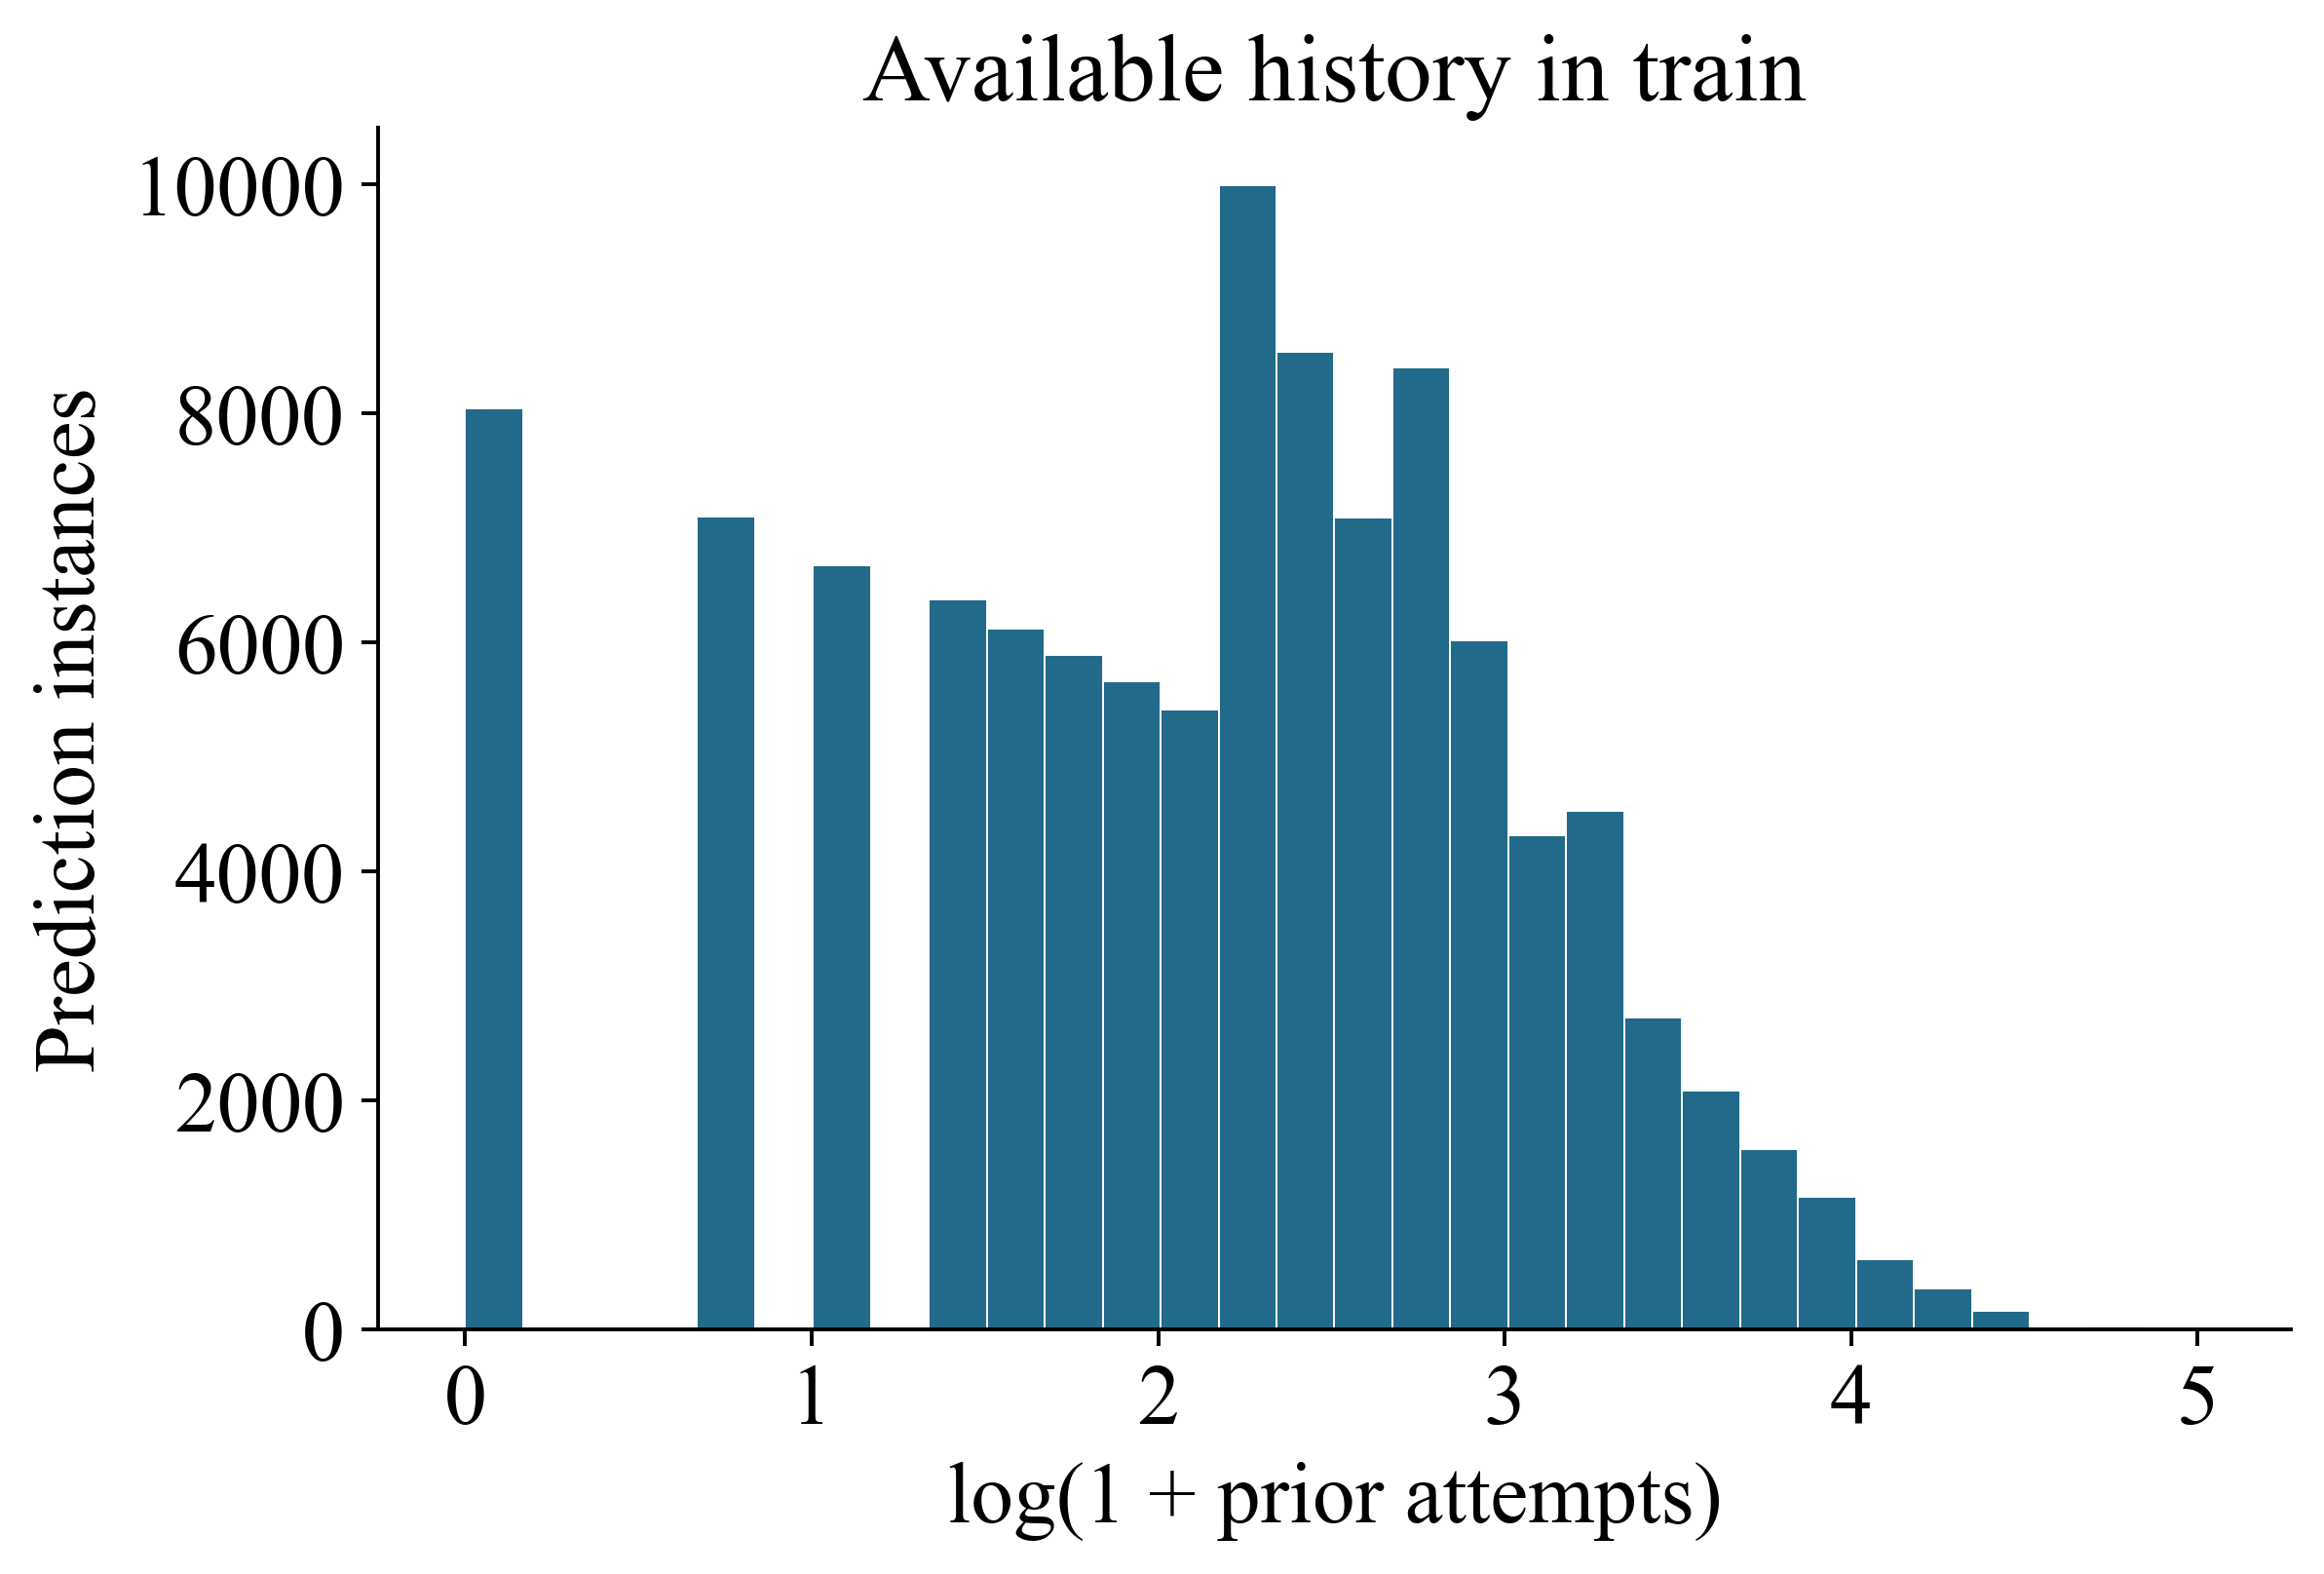

In [10]:
fig, ax = plt.subplots(figsize=(6.7, 4.5), layout="constrained")
ax.hist(
    tr.history_log_n,
    bins=30,
    color="#216A89",
    edgecolor="white",
    linewidth=0.4,
)
ax.set(
    xlabel="log(1 + prior attempts)",
    ylabel="Prediction instances",
    title="Available history in train",
)
ax.spines[["top", "right"]].set_visible(False)
tr[["history_log_n"]].to_csv(
    ROOT / "artifacts/02_history_distribution.csv", index=False
)
save_figure(fig, "02_history_distribution")
plt.show()


Опыт распределён неравномерно: отдельно выделяются запросы без прошлой истории и длинный правый хвост. Для последующего анализа ошибок необходимы режимы холодного старта и накопленного опыта. Более длинная история не тождественна большей компетентности.

## Локальные изменения программы

Сколько редактирований содержат прошлые эпизоды? Все попытки train сохраняются, включая короткие и неуспешные. Логарифмическая шкала улучшает видимость центра и длинного хвоста, не меняя исходных наблюдений.

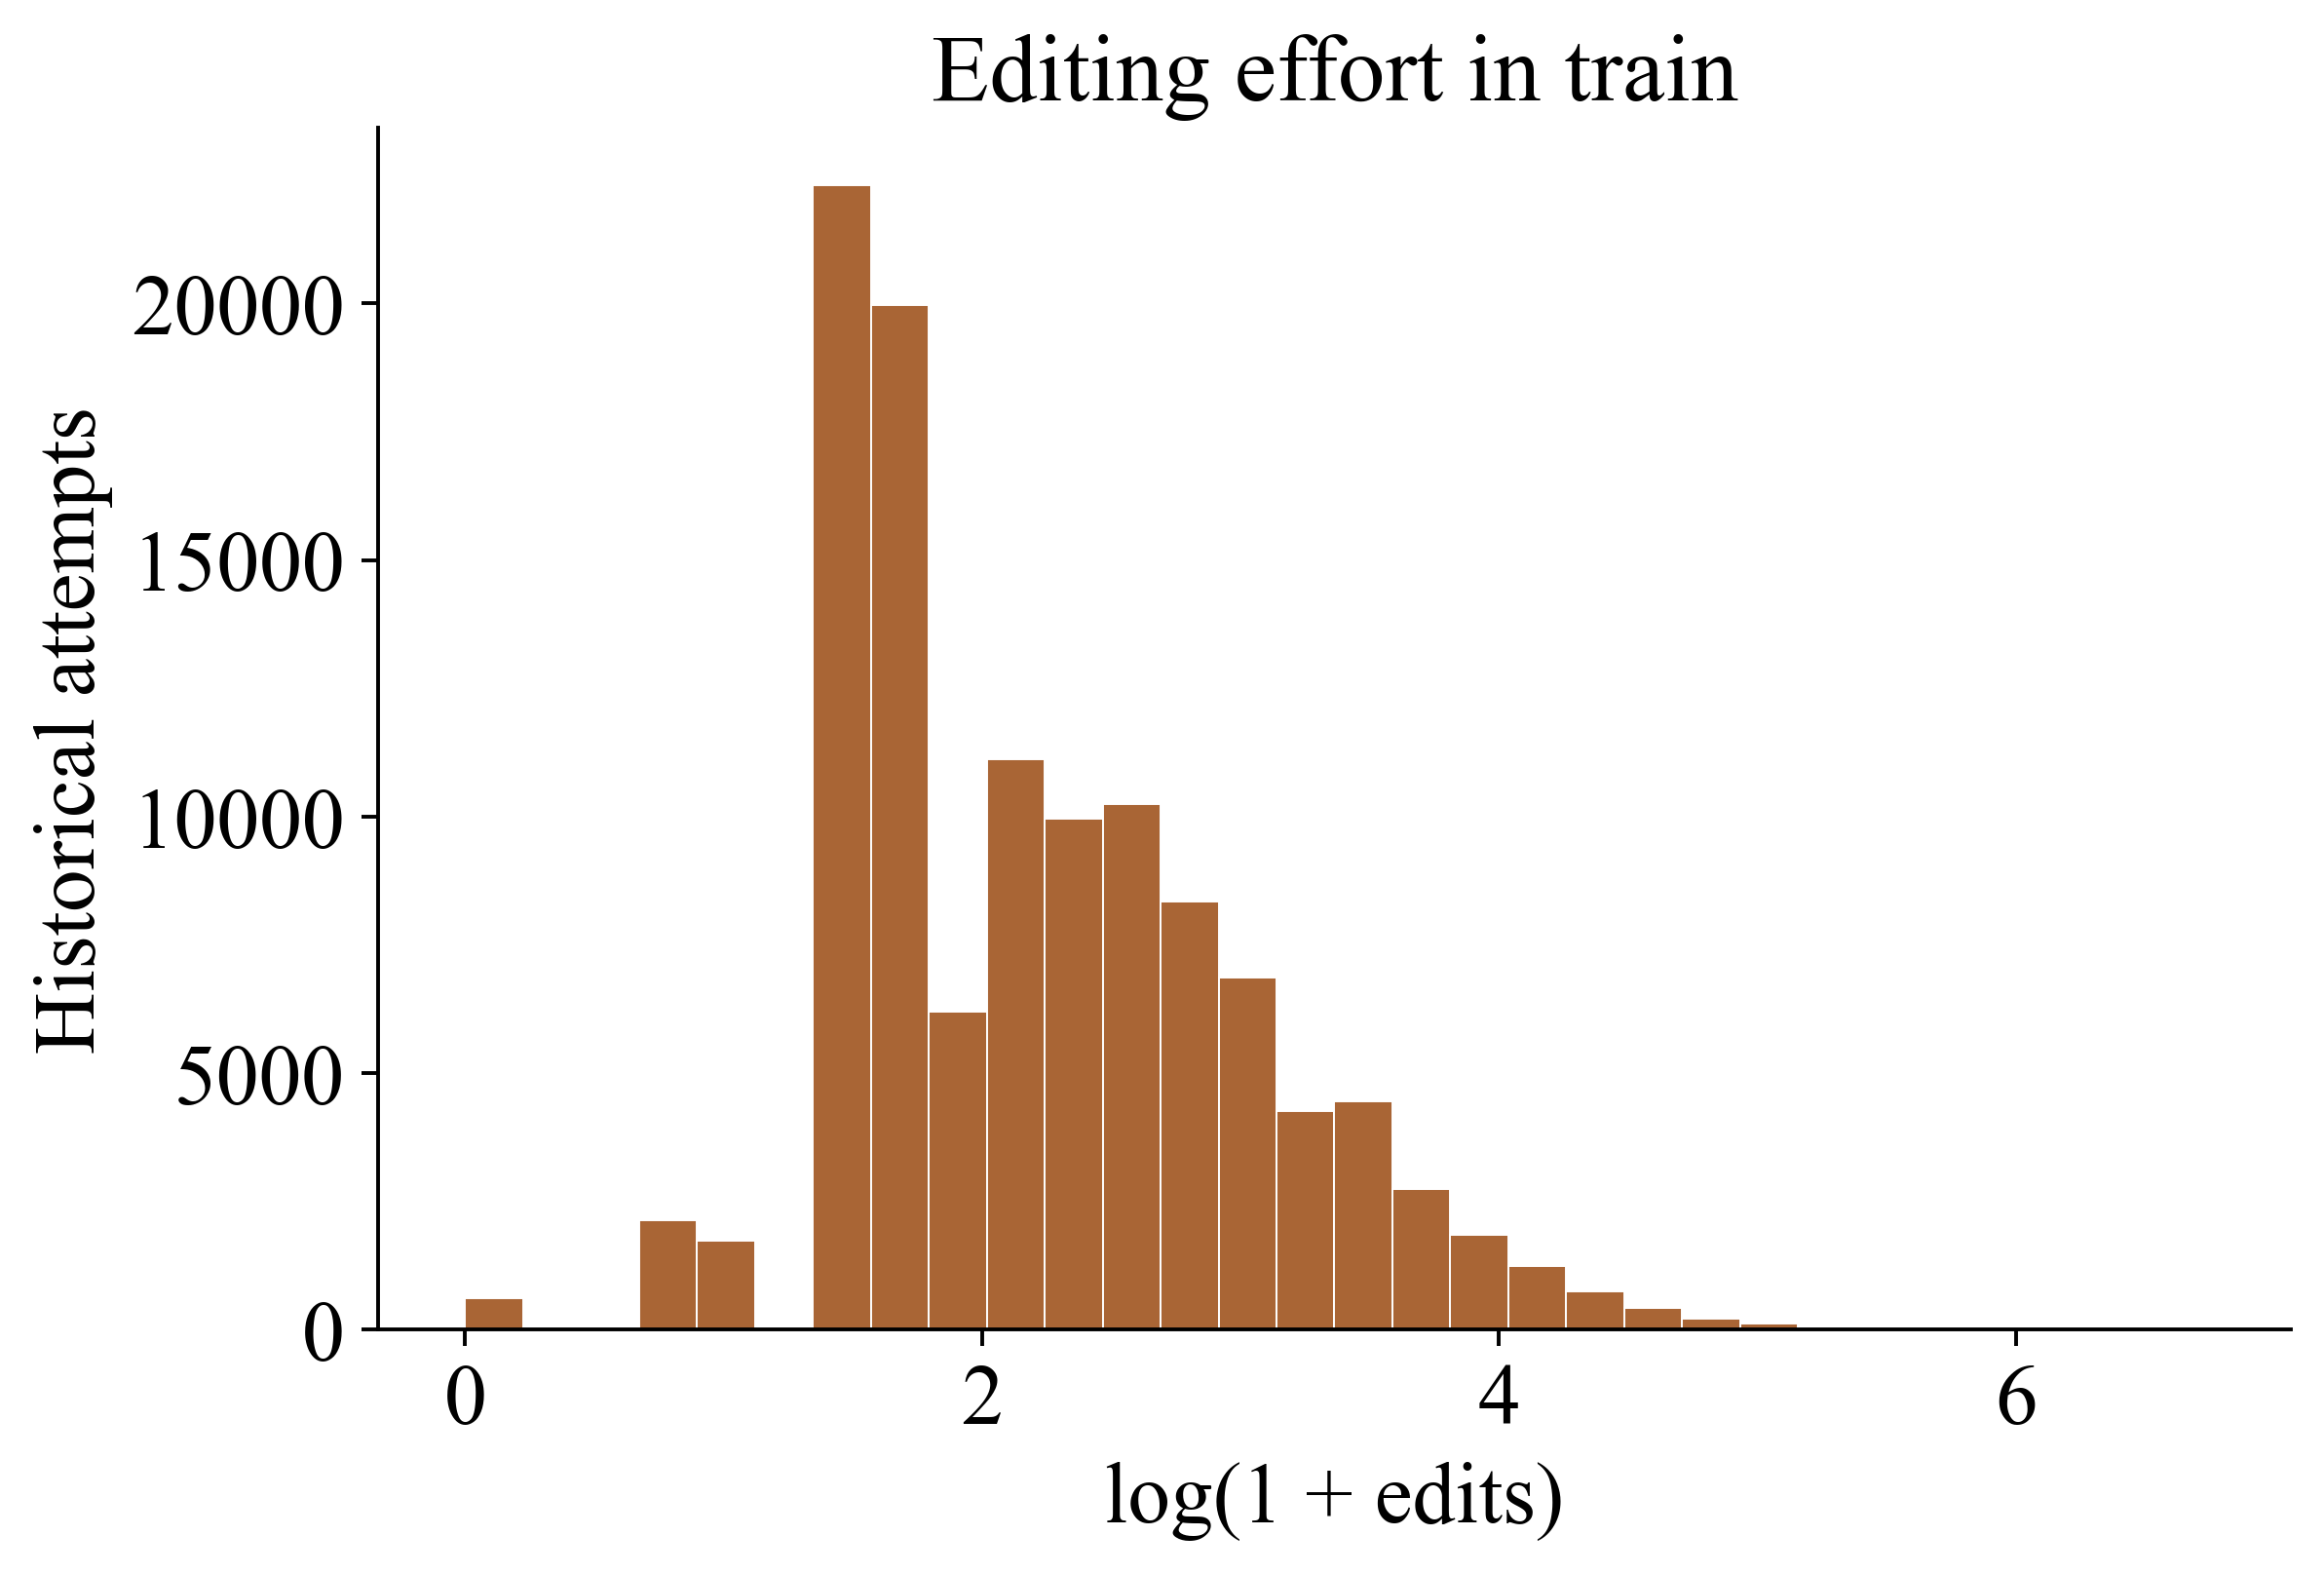

In [11]:
fig, ax = plt.subplots(figsize=(6.7, 4.5), layout="constrained")
ax.hist(
    train_ep.log_n_edits,
    bins=30,
    color="#A96535",
    edgecolor="white",
    linewidth=0.4,
)
ax.set(
    xlabel="log(1 + edits)",
    ylabel="Historical attempts",
    title="Editing effort in train",
)
ax.spines[["top", "right"]].set_visible(False)
train_ep[["log_n_edits"]].to_csv(
    ROOT / "artifacts/02_edit_distribution.csv", index=False
)
save_figure(fig, "02_edit_distribution")
plt.show()


Основная масса прошлых попыток содержит умеренное число редактирований, но сохраняется длинный правый хвост. Логарифмическая шкала позволяет одновременно видеть типичные и редкие траектории. Это ретроспективное описание полных попыток; прогнозные признаки используют только доступные префиксы.

## Аналитическая выборка для матриц

Чтобы учащиеся с длинной историей не получали чрезмерный вес, для матриц детерминированно выбирается одна прогнозная точка каждого учащегося train. Выбор не использует целевую метку. Для корреляционных и информационных матриц нужны все шесть предикторов, поэтому их популяция ограничена точками с доступной историей. Численность указывается на каждом рисунке. Этот анализ описательный; он не заменяет обучение на полном train.

Нормированная взаимная информация оценивается после дискретизации максимум на 10 квантильных интервалов: $2I(X;Z)/(H(X)+H(Z))$. Это оценка для указанных интервалов, а не универсальная шкала зависимости непрерывных величин. Матрица XGBoost направленная: столбец — предиктор, строка — предсказываемый признак.

In [12]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from sklearn.metrics import normalized_mutual_info_score
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBRegressor

ranked = tr.assign(
    eda_order=tr.id.map(
        lambda i: hashlib.sha256(f"{SEED}:eda:{i}".encode()).hexdigest()
    )
)
eda_sample = (
    ranked.sort_values("eda_order")
    .drop_duplicates("student")
    .dropna(subset=EDA_COLS)
    .copy()
)
assert eda_sample.student.is_unique and len(eda_sample) > 500
eda_sample[["id", "student", "fold"] + EDA_COLS + ["y"]].to_csv(
    ROOT / "artifacts/02_matrix_source.csv", index=False
)

CORR_CMAP = LinearSegmentedColormap.from_list(
    "alpha_correlation", ["#245B82", "#F4F2E8", "#933958"]
)
MI_CMAP = LinearSegmentedColormap.from_list(
    "alpha_information", ["#FFF7DF", "#D4AE72", "#457986", "#192F51"]
)
PRED_CMAP = LinearSegmentedColormap.from_list(
    "alpha_predictability", ["#9B4050", "#F4F2E8", "#68A5A0", "#173C5A"]
)


def matrix_figure(
    values: np.ndarray,
    title: str,
    name: str,
    cmap,
    vmin: float,
    vmax: float,
    scale_label: str,
    directed: bool = False,
) -> None:
    """Use a compact six-variable matrix with fixed readable font sizes."""
    labels = EDA_TICKS
    side = max(5.6, 0.68 * len(labels) + 2.7)
    fig, ax = plt.subplots(figsize=(side, side - 0.25), layout="constrained")
    kwargs = (
        {"norm": TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)}
        if vmin < 0
        else {"vmin": vmin, "vmax": vmax}
    )
    artist = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, **kwargs)
    ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title(
        title + f"\nTrain: n = {len(eda_sample):,} learners", fontsize=20
    )
    if directed:
        ax.set_xlabel("Predictor")
        ax.set_ylabel("Predicted variable")
    for i in range(len(labels)):
        for j in range(len(labels)):
            value = values[i, j]
            if np.isfinite(value):
                red, green, blue, _ = artist.cmap(artist.norm(value))
                luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
                text = f"{value:.2f}".replace("-", "−")
                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=18,
                    color="white" if luminance < 0.52 else "#171717",
                )
    cbar = fig.colorbar(
        artist,
        ax=ax,
        fraction=0.045,
        pad=0.025,
        ticks=[vmin, (vmin + vmax) / 2, vmax],
    )
    cbar.set_label(scale_label, fontsize=18)
    pd.DataFrame(values, index=EDA_LABELS, columns=EDA_LABELS).to_csv(
        ROOT / "artifacts" / f"{name}.csv"
    )
    save_figure(fig, name)
    plt.show()


## Корреляционная структура

Матрица Spearman показывает направление и силу монотонных связей между опытом, результативностью, редактированием, вложенностью программы и учебной сложностью. Различие между положительной и отрицательной связью обозначено расходящейся палитрой. Знак минуса в аннотациях — математический символ $−$.

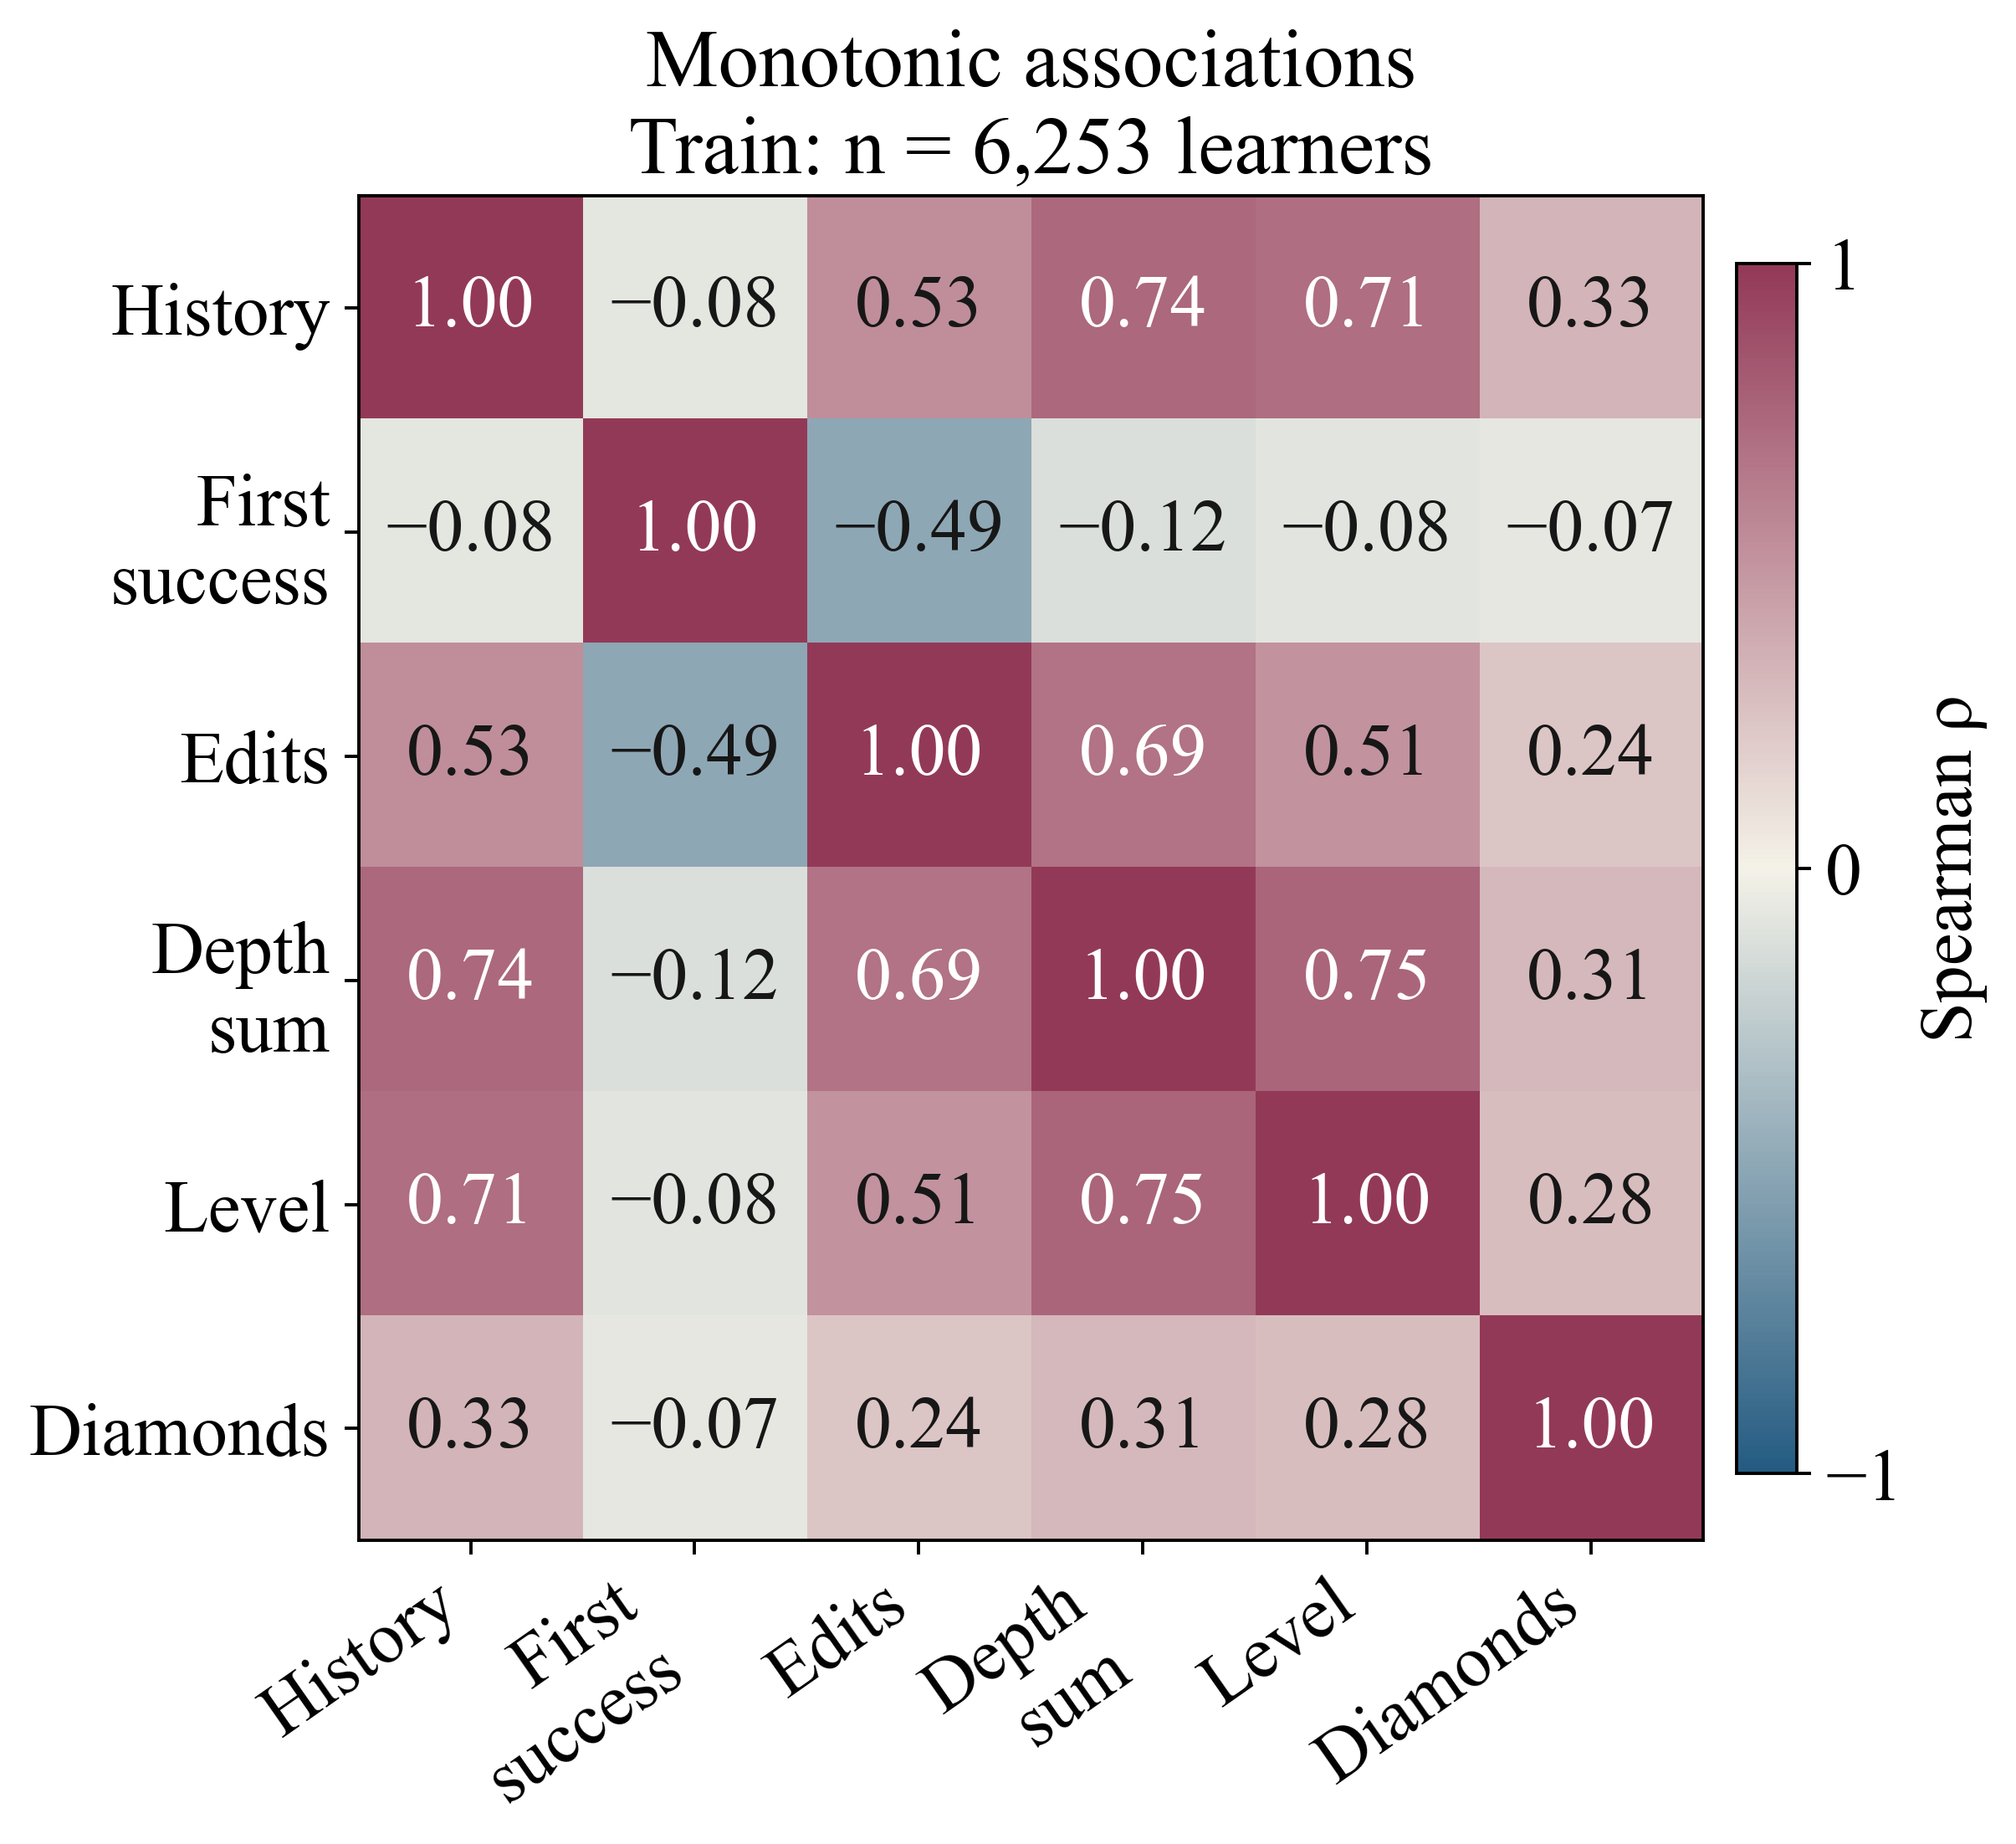

In [13]:
spearman_matrix = eda_sample[EDA_COLS].corr(method="spearman").to_numpy()
matrix_figure(
    spearman_matrix,
    "Monotonic associations",
    "02_spearman_matrix",
    CORR_CMAP,
    -1,
    1,
    "Spearman ρ",
)


Длина истории связана с разделом задания (ρ = 0,71) и накопленной глубиной кода (ρ = 0,74); число редактирований отрицательно связано с прежней успешностью (ρ = −0,49). Поэтому влияние опыта нельзя интерпретировать отдельно от сложности пройденных заданий. Матрица описывает 6 253 учащихся с полными значениями выбранных переменных.

## Матрица взаимной информации

Существуют ли зависимости, не ограниченные монотонной формой? Нормированная взаимная информация симметрична, не имеет знака и зависит от дискретизации. Высокое значение не означает причинное влияние. На диагонали показано тождественное сравнение переменной с собой.

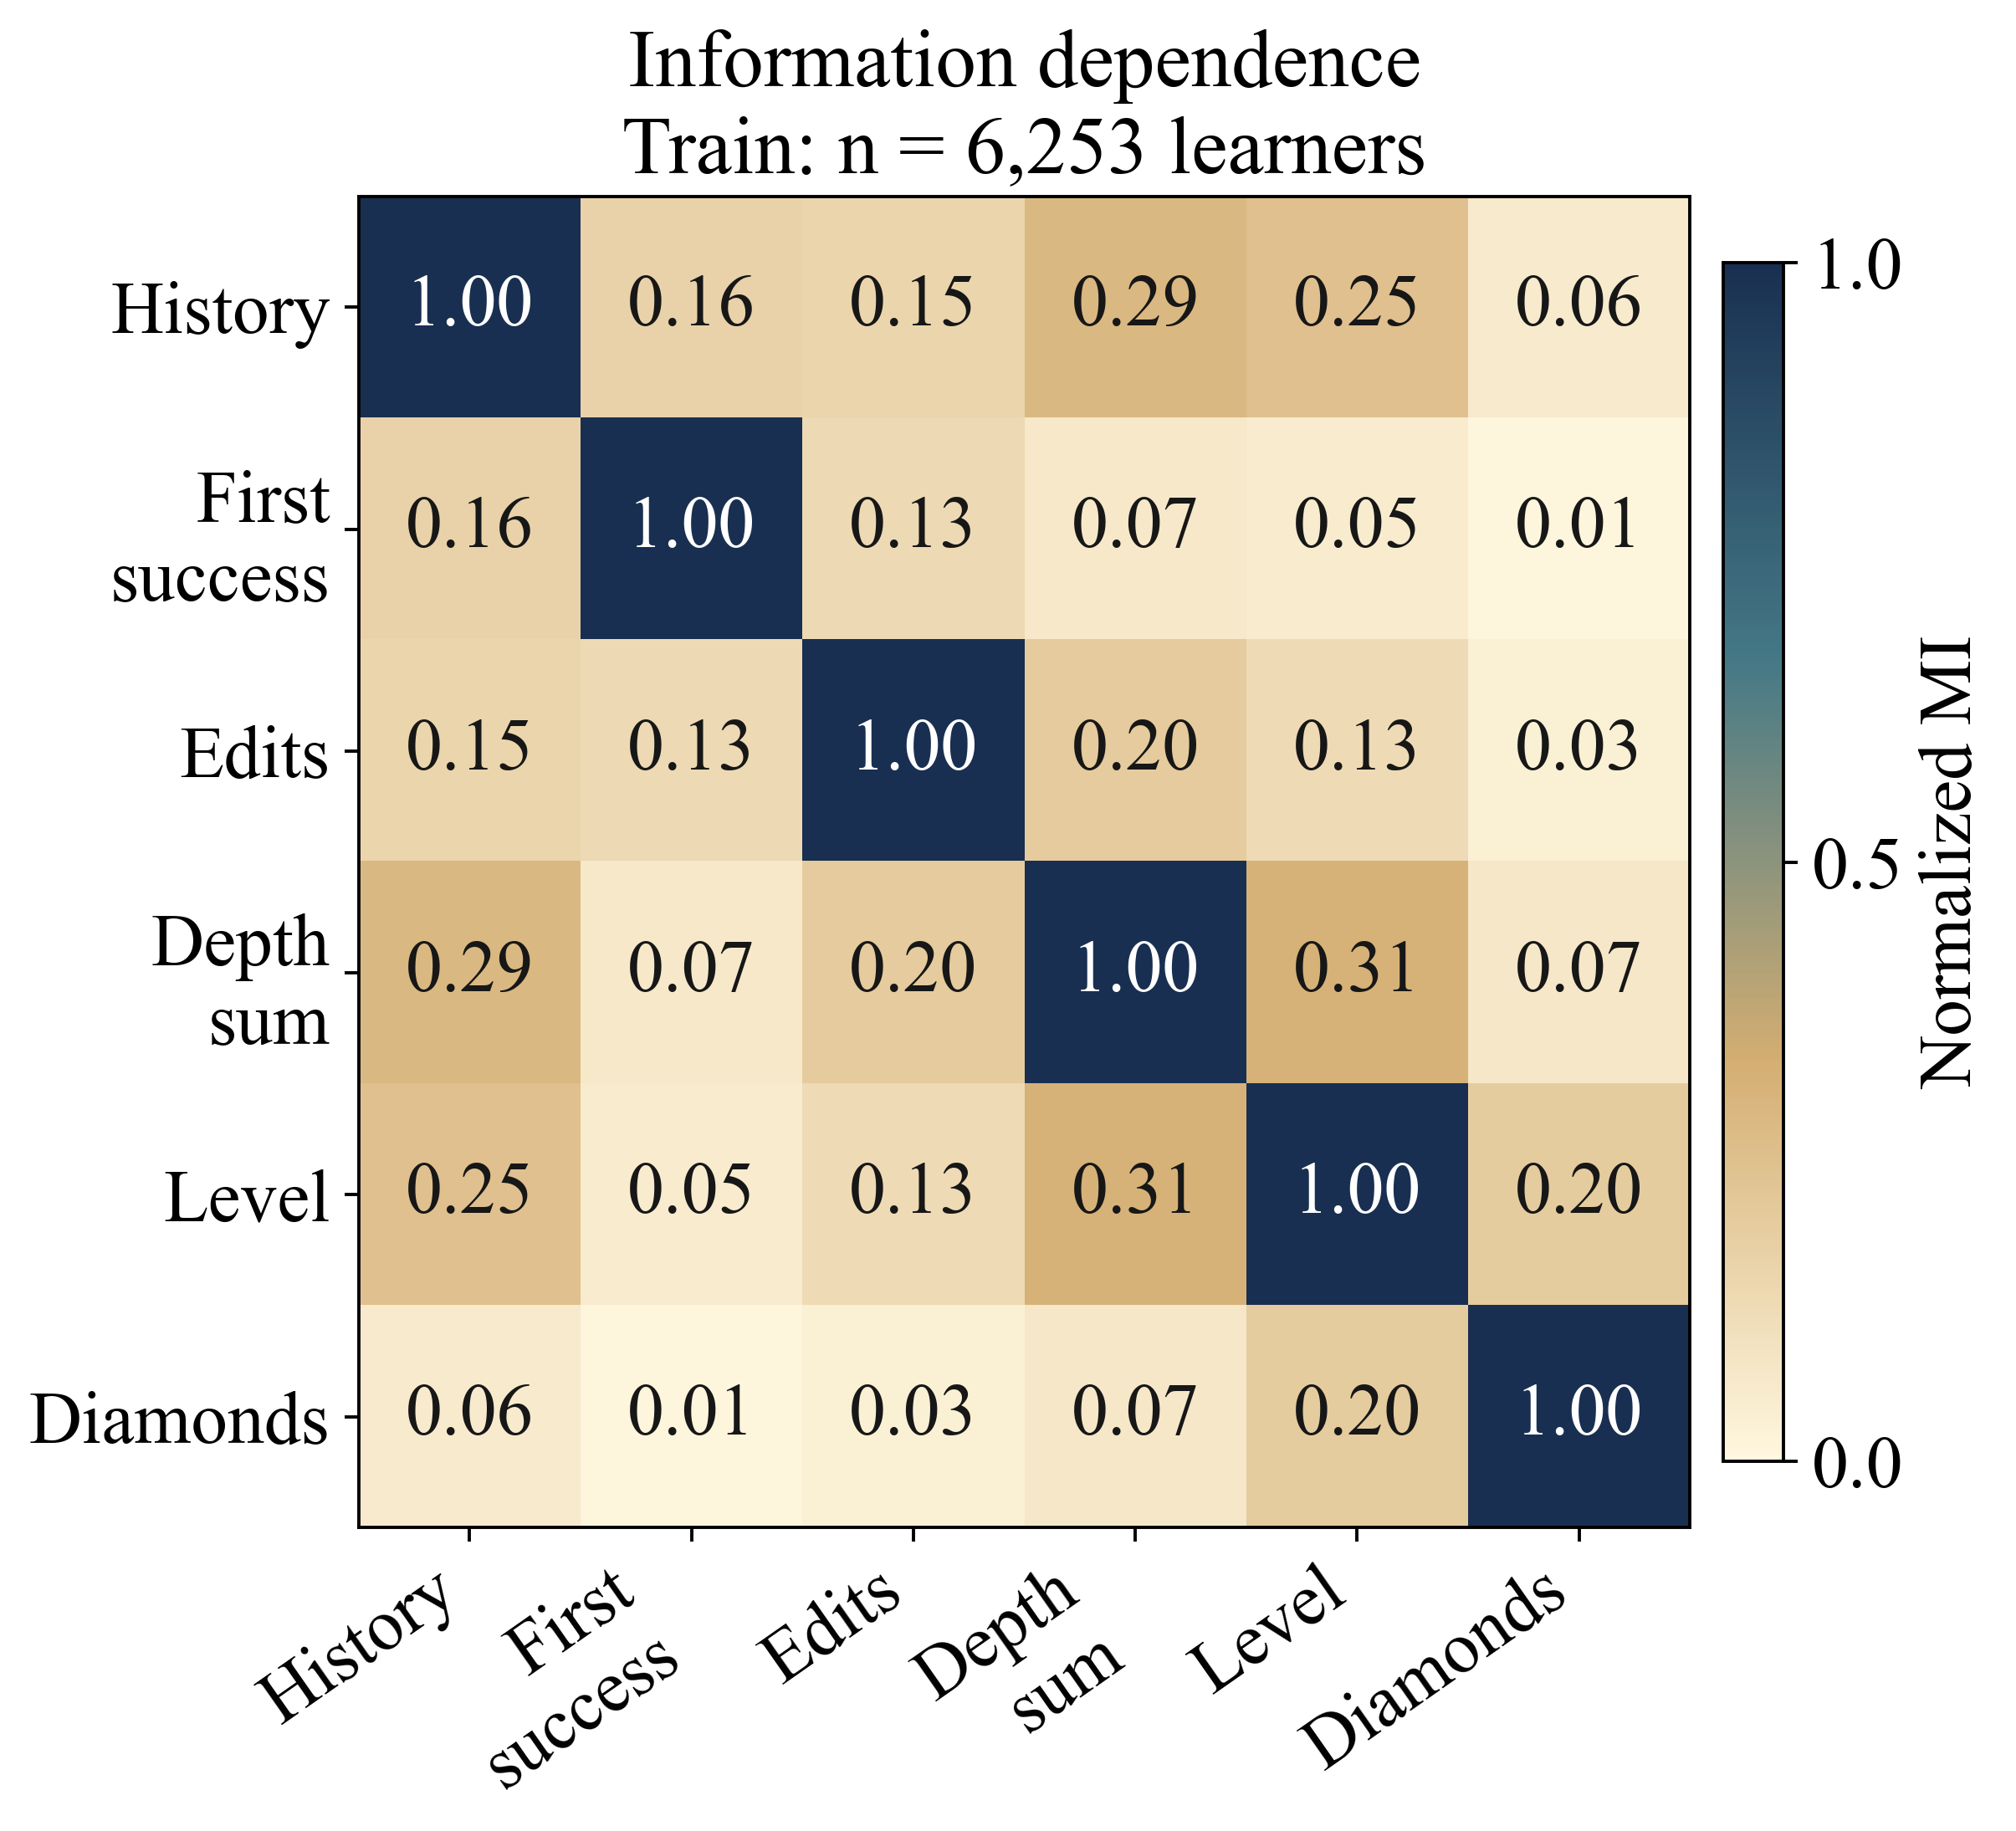

In [14]:
binned = pd.DataFrame(index=eda_sample.index)
for col in EDA_COLS:
    v = eda_sample[col]
    if v.nunique() <= 10:
        binned[col] = pd.factorize(v, sort=True)[0]
    else:
        binned[col] = pd.qcut(v, q=10, labels=False, duplicates="drop")
mi_matrix = np.array(
    [
        [
            normalized_mutual_info_score(
                binned[a], binned[c], average_method="arithmetic"
            )
            for c in EDA_COLS
        ]
        for a in EDA_COLS
    ]
)
matrix_figure(
    mi_matrix,
    "Information dependence",
    "02_mutual_information_matrix",
    MI_CMAP,
    0,
    1,
    "Normalized MI",
)


Взаимная информация обнаруживает зависимость длины истории и прежней успешности (0,16), несмотря на слабую корреляцию Спирмена. Нормированная MI зависит от дискретизации и не имеет знака; её величины не сопоставляются напрямую с корреляцией. Доли успеха также зависят от числа наблюдавшихся запусков по определению.

## Нелинейная предсказуемость на основе XGBoost

Для каждой пары XGBoost предсказывает один признак по другому. Предсказания вычисляются out-of-fold на трёх фиксированных фолдах учащихся. Показатель $R^2_{OOF}=1-\sum(z-\hat z)^2/\sum(z-\bar z_{train\,fold})^2$ сравнивает модель со средним, вычисленным без оцениваемого фолда. Отрицательные значения сохраняются: модель может быть хуже такого ориентира. Диагональ не оценивается, поскольку предсказание переменной по самой себе тривиально.

Бюджет ограничен 100 деревьями глубины 3 для каждой направленной пары; гиперпараметры здесь не оптимизируются. Это исследование структуры входов, не сравнение качества итоговых моделей. [API XGBoost](https://xgboost.readthedocs.io/en/release_3.0.0/python/python_api.html).

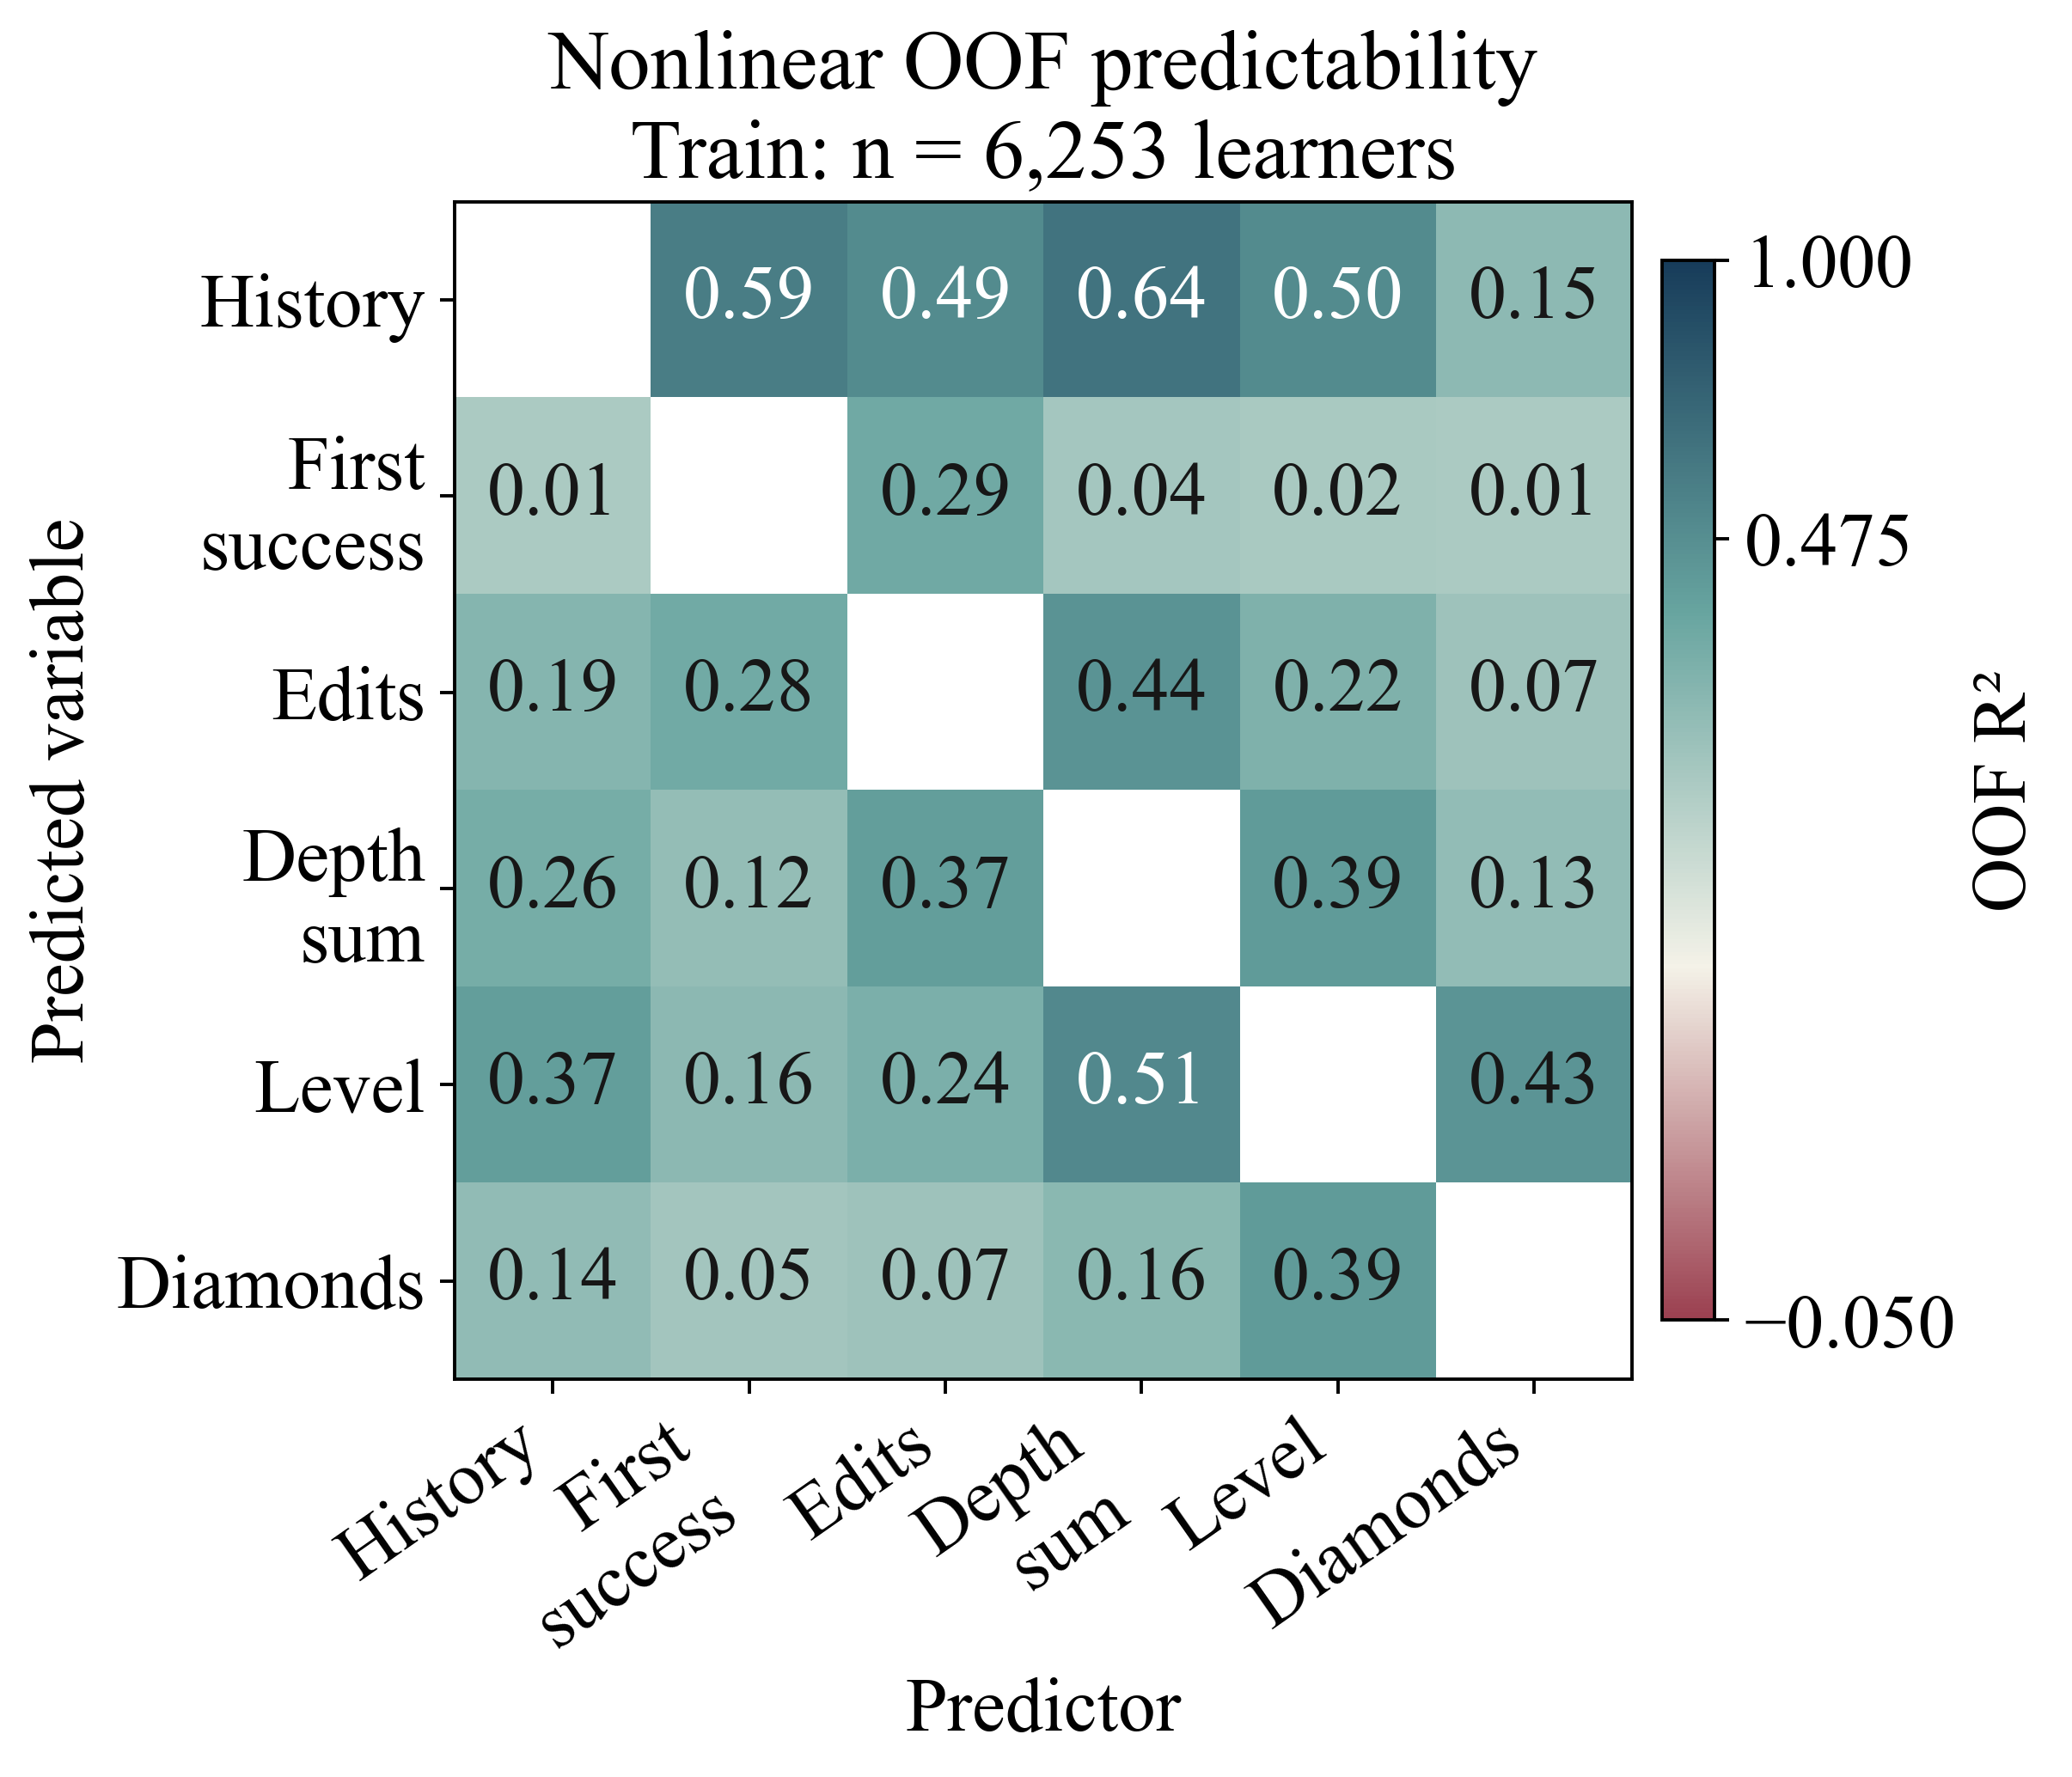

In [15]:
xgb_matrix = np.full((len(EDA_COLS), len(EDA_COLS)), np.nan)
for target_index, target in enumerate(EDA_COLS):
    truth = eda_sample[target].to_numpy()
    reference = np.zeros(len(eda_sample))
    for fold in range(3):
        mask = eda_sample.fold.to_numpy() == fold
        reference[mask] = truth[~mask].mean()
    denominator = np.sum((truth - reference) ** 2)
    assert denominator > 0
    for predictor_index, predictor in enumerate(EDA_COLS):
        if predictor_index == target_index:
            continue
        pred = np.zeros(len(eda_sample))
        for fold in range(3):
            mask = eda_sample.fold.to_numpy() == fold
            model = XGBRegressor(
                n_estimators=100,
                max_depth=3,
                learning_rate=0.05,
                objective="reg:squarederror",
                tree_method="hist",
                n_jobs=2,
                random_state=SEED,
                verbosity=0,
            )
            model.fit(eda_sample.loc[~mask, [predictor]], truth[~mask])
            pred[mask] = model.predict(eda_sample.loc[mask, [predictor]])
        xgb_matrix[target_index, predictor_index] = (
            1 - np.sum((truth - pred) ** 2) / denominator
        )
lo = min(-0.05, float(np.floor(np.nanmin(xgb_matrix) * 20) / 20))
matrix_figure(
    xgb_matrix,
    "Nonlinear OOF predictability",
    "02_xgboost_dependence_matrix",
    PRED_CMAP,
    lo,
    1,
    "OOF R²",
    directed=True,
)


Направленная матрица показывает, насколько один признак предсказывается по другому вне обучающего фолда. Например, длина истории предсказывается по глубине кода с R² ≈ 0,64, а обратное направление даёт ≈ 0,26. Асимметрия закономерна для предсказательной меры; она не задаёт причинное направление. Предсказуемость длины истории по доле успехов частично может отражать дискретность долей при разных знаменателях.

## Связь предикторов с основным результатом

Какие из выбранных измерений содержат информацию о правильности первого запуска? Здесь взаимная информация с бинарной целью оценивается методом ближайших соседей в натуральных единицах (натах). Идентификатор учащегося не используется. Значения служат описанию обучающей выборки; окончательная полезность признаков требует OOF-сравнения и абляций.

[Метод оценки mutual_info_classif](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html).

In [16]:
mi_target = mutual_info_classif(
    eda_sample[EDA_COLS],
    eda_sample.y,
    discrete_features=[False, False, False, False, True, True],
    n_neighbors=5,
    random_state=SEED,
)
association = pd.DataFrame(
    {
        "Предиктор": EDA_LABELS,
        "n": len(eda_sample),
        "Spearman с y": [
            spearmanr(eda_sample[c], eda_sample.y).statistic for c in EDA_COLS
        ],
        "MI с y, нат": mi_target,
    }
)
table(
    association,
    "Таблица 14. Монотонная и информационная связь с целью",
    "02_target_associations",
)


Таблица 14. Монотонная и информационная связь с целью

,Предиктор,n,Spearman с y,"MI с y, нат"
0,History,6253,-0.148,0.019
1,First success,6253,0.177,0.025
2,Edits,6253,-0.165,0.022
3,Depth sum,6253,-0.124,0.016
4,Level,6253,-0.248,0.037
5,Diamonds,6253,-0.144,0.028


Среди шести исследованных признаков раздел задания имеет наибольшую оценку MI с первым успехом (0,037 нат); прежняя успешность положительно связана с текущей (ρ = 0,177). Одномерные связи умеренны и не определяют качество многомерной модели. Эти результаты служат описанием train, а не процедурой отбора по тесту.

## Сдвиг между train и validation

KS описывает различия распределений признаков и не используется здесь как тест независимых событий. Повторные наблюдения внутри учащегося учитываются при последующем bootstrap. Закрытый test остаётся вне этой диагностики. Отдельно показан сдвиг доли успеха — он влияет на оценку калибровки.

In [17]:
shift_rows = []
for col, label in zip(EDA_COLS + ["y"], EDA_LABELS + ["Первый успех"]):
    ks = ks_2samp(tr[col].dropna(), va[col].dropna()).statistic
    shift_rows.append(
        [
            label,
            int(tr[col].notna().sum()),
            int(va[col].notna().sum()),
            tr[col].median(),
            va[col].median(),
            ks,
        ]
    )
table(
    pd.DataFrame(
        shift_rows,
        columns=[
            "Предиктор",
            "n train",
            "n validation",
            "Медиана train",
            "Медиана validation",
            "KS",
        ],
    ),
    "Таблица 15. Различия распределений",
    "02_distribution_shift",
)


Таблица 15. Различия распределений

,Предиктор,n train,n validation,Медиана train,Медиана validation,KS
0,History,108877,23326,2.197,2.197,0.012
1,First success,100670,21543,0.500,0.500,0.012
2,Edits,100834,21581,1.946,1.936,0.014
3,Depth sum,100834,21581,4.333,4.286,0.025
4,Level,108877,23326,2.000,2.000,0.015
5,Diamonds,108877,23326,0.000,0.000,0.012
6,Первый успех,108877,23326,0.000,0.000,0.001


Для рассмотренных переменных расстояния KS между train и validation находятся в пределах 0,025; наиболее заметное различие относится к глубине кода. Это небольшие одномерные сдвиги, но они не доказывают совпадение совместных распределений или переносимость на другой период. P-values не интерпретируются как для независимых попыток одного ученика.

## Коллинеарность и обучение преобразований

Почти дублирующиеся признаки отмечаются по модулю Spearman выше 0.995, но не удаляются только ради улучшения результатов. Регуляризованные линейные модели и деревья имеют разные механизмы устойчивости. Импутация с индикаторами и масштабирование в этом примере обучены только на train; во внутреннем CV они будут заново обучены внутри каждого training-fold. Балансировка классов не включается автоматически, поскольку основной критерий оценивает вероятности исходов естественной выборки.

In [18]:
numeric_features = [c for c in feature_names if c != "problem"]
preprocessor = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True), StandardScaler()
)
z_train = preprocessor.fit_transform(tr[numeric_features])
z_validation = preprocessor.transform(va[numeric_features])
assert np.isfinite(z_train).all() and np.isfinite(z_validation).all()
assert not set(
    ["student", "y", "effort_runs", "effort_observed"]
).intersection(feature_names)
correlation = tr[numeric_features].corr(method="spearman").abs()
redundancy = [
    (a, c, correlation.loc[a, c])
    for i, a in enumerate(numeric_features)
    for c in numeric_features[i + 1 :]
    if correlation.loc[a, c] > 0.995
]
pd.DataFrame(
    redundancy, columns=["feature_1", "feature_2", "absolute_spearman"]
).to_csv(ROOT / "artifacts/02_redundancy.csv", index=False)
table(
    pd.DataFrame(
        [
            ["Числовые признаки до преобразования", len(numeric_features)],
            ["Числовые признаки после импутации", z_train.shape[1]],
            ["Категориальный идентификатор задания", 1],
            ["Пары с |Spearman| > 0.995", len(redundancy)],
        ],
        columns=["Характеристика", "Число"],
    ),
    "Таблица 16. Итоговое пространство признаков",
    "02_feature_space",
)


Таблица 16. Итоговое пространство признаков

,Характеристика,Число
0,Числовые признаки до преобразования,51
1,Числовые признаки после импутации,73
2,Категориальный идентификатор задания,1
3,Пары с |Spearman| > 0.995,2


51 числовой предиктор после добавления индикаторов пропусков даёт 73 числовых входа; идентификатор задания кодируется отдельно. Обнаружены две почти монотонно дублирующие пары: длина истории и её логарифм, а также UNKNOWN и индикатор невалидного кода. Они оставлены как разные представления для регуляризованных и древесных моделей; отдельная причинная интерпретация их коэффициентов не выполняется. Преобразования в обучении переобучаются внутри каждого фолда.

## Связь редактирования и повторных запусков

Отражают ли два вида действия один и тот же процесс? Совместная плотность использует все исторические эпизоды train. Она позволяет увидеть сочетания активного редактирования и многократного запуска, которые одномерная гистограмма не раскрывает.

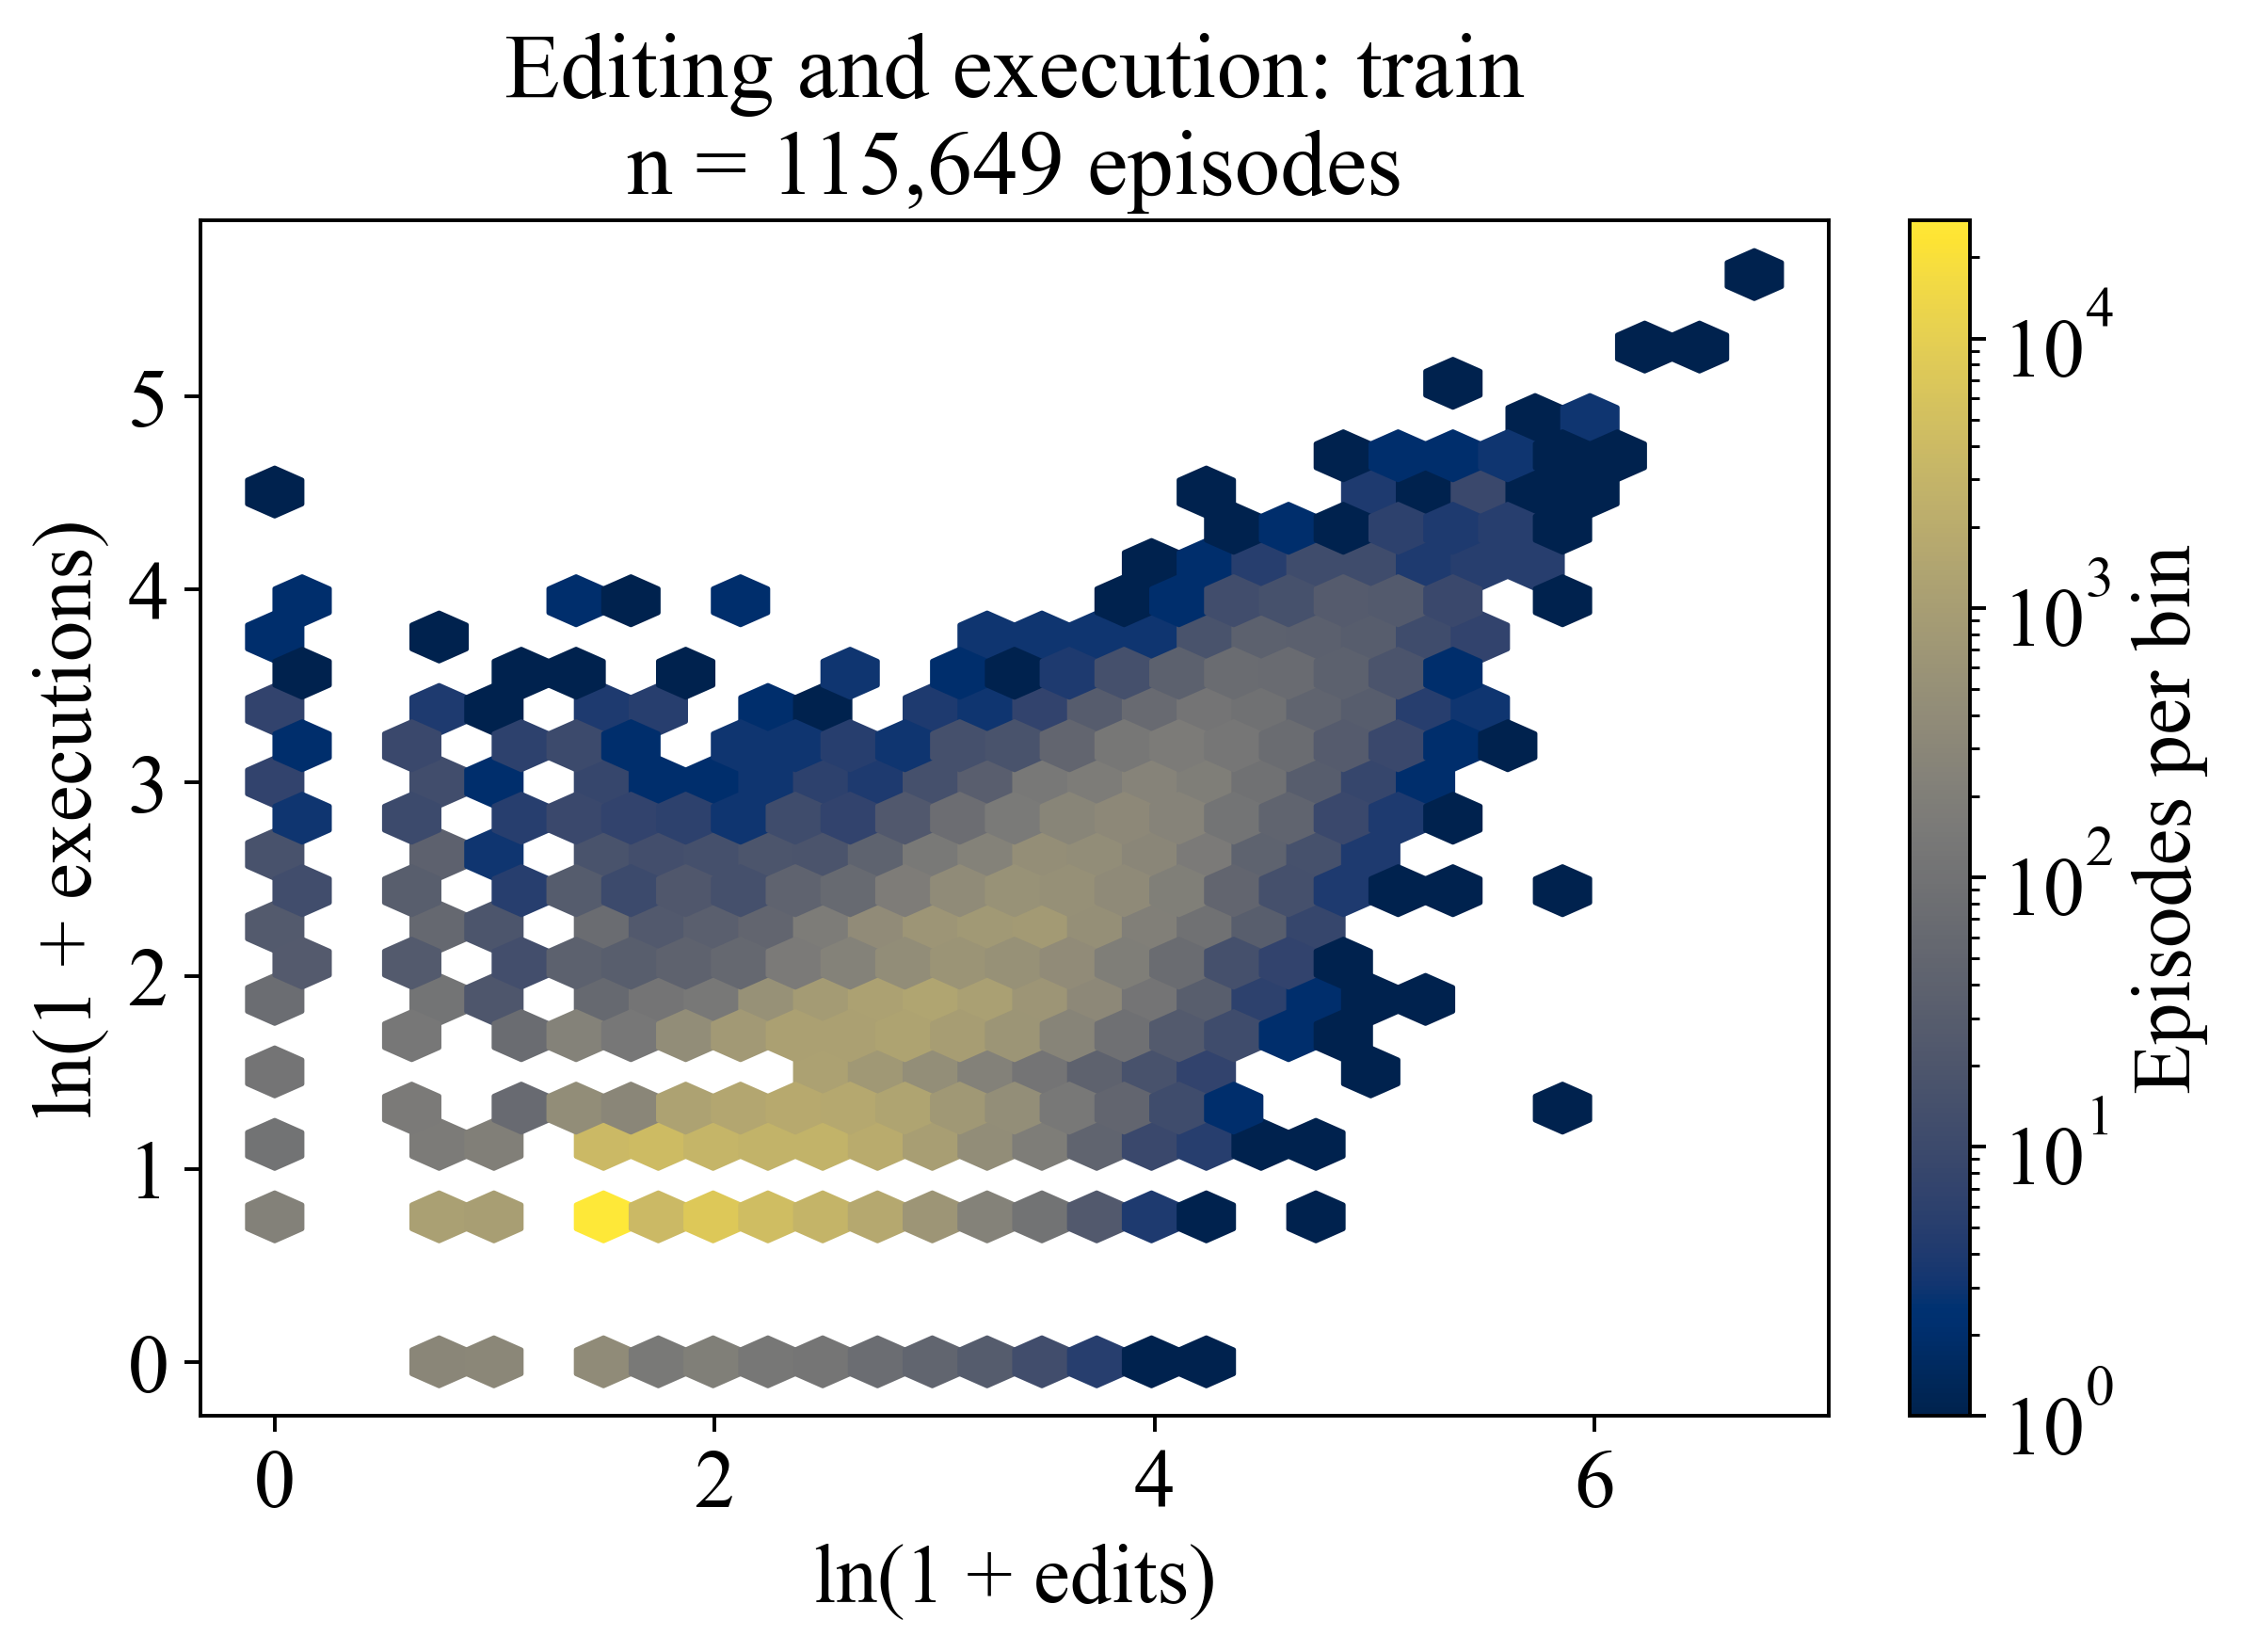

In [19]:
action_source = train_ep[["log_n_edits", "log_n_executions"]].copy()
action_source.to_csv(
    ROOT / "artifacts/02_action_density_source.csv", index=False
)
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(6.7, 4.9), layout="constrained")
artist = ax.hexbin(
    action_source.log_n_edits,
    action_source.log_n_executions,
    gridsize=27,
    mincnt=1,
    norm=LogNorm(),
    cmap="cividis",
)
ax.set(
    xlabel="ln(1 + edits)",
    ylabel="ln(1 + executions)",
    title=f"Editing and execution: train\nn = {len(action_source):,} episodes",
)
fig.colorbar(artist, ax=ax, label="Episodes per bin")
save_figure(fig, "02_action_density")
plt.show()


Число редактирований и запусков положительно связано, однако при одинаковом числе редактирований встречается разное число запусков. Нулевая полоса запусков отражает попытки без выполнения программы. Поэтому эти каналы не заменяют друг друга; события без запуска не кодируются как наблюдённая неудача.

## Распределение исторической структуры кода по исходу

Отличаются ли доступные до прогноза структурные характеристики при успешном и неуспешном первом запуске? Сравнение условных распределений не является оценкой качества модели. Показаны только строки с наблюдаемым прошлым; код текущей попытки не используется.

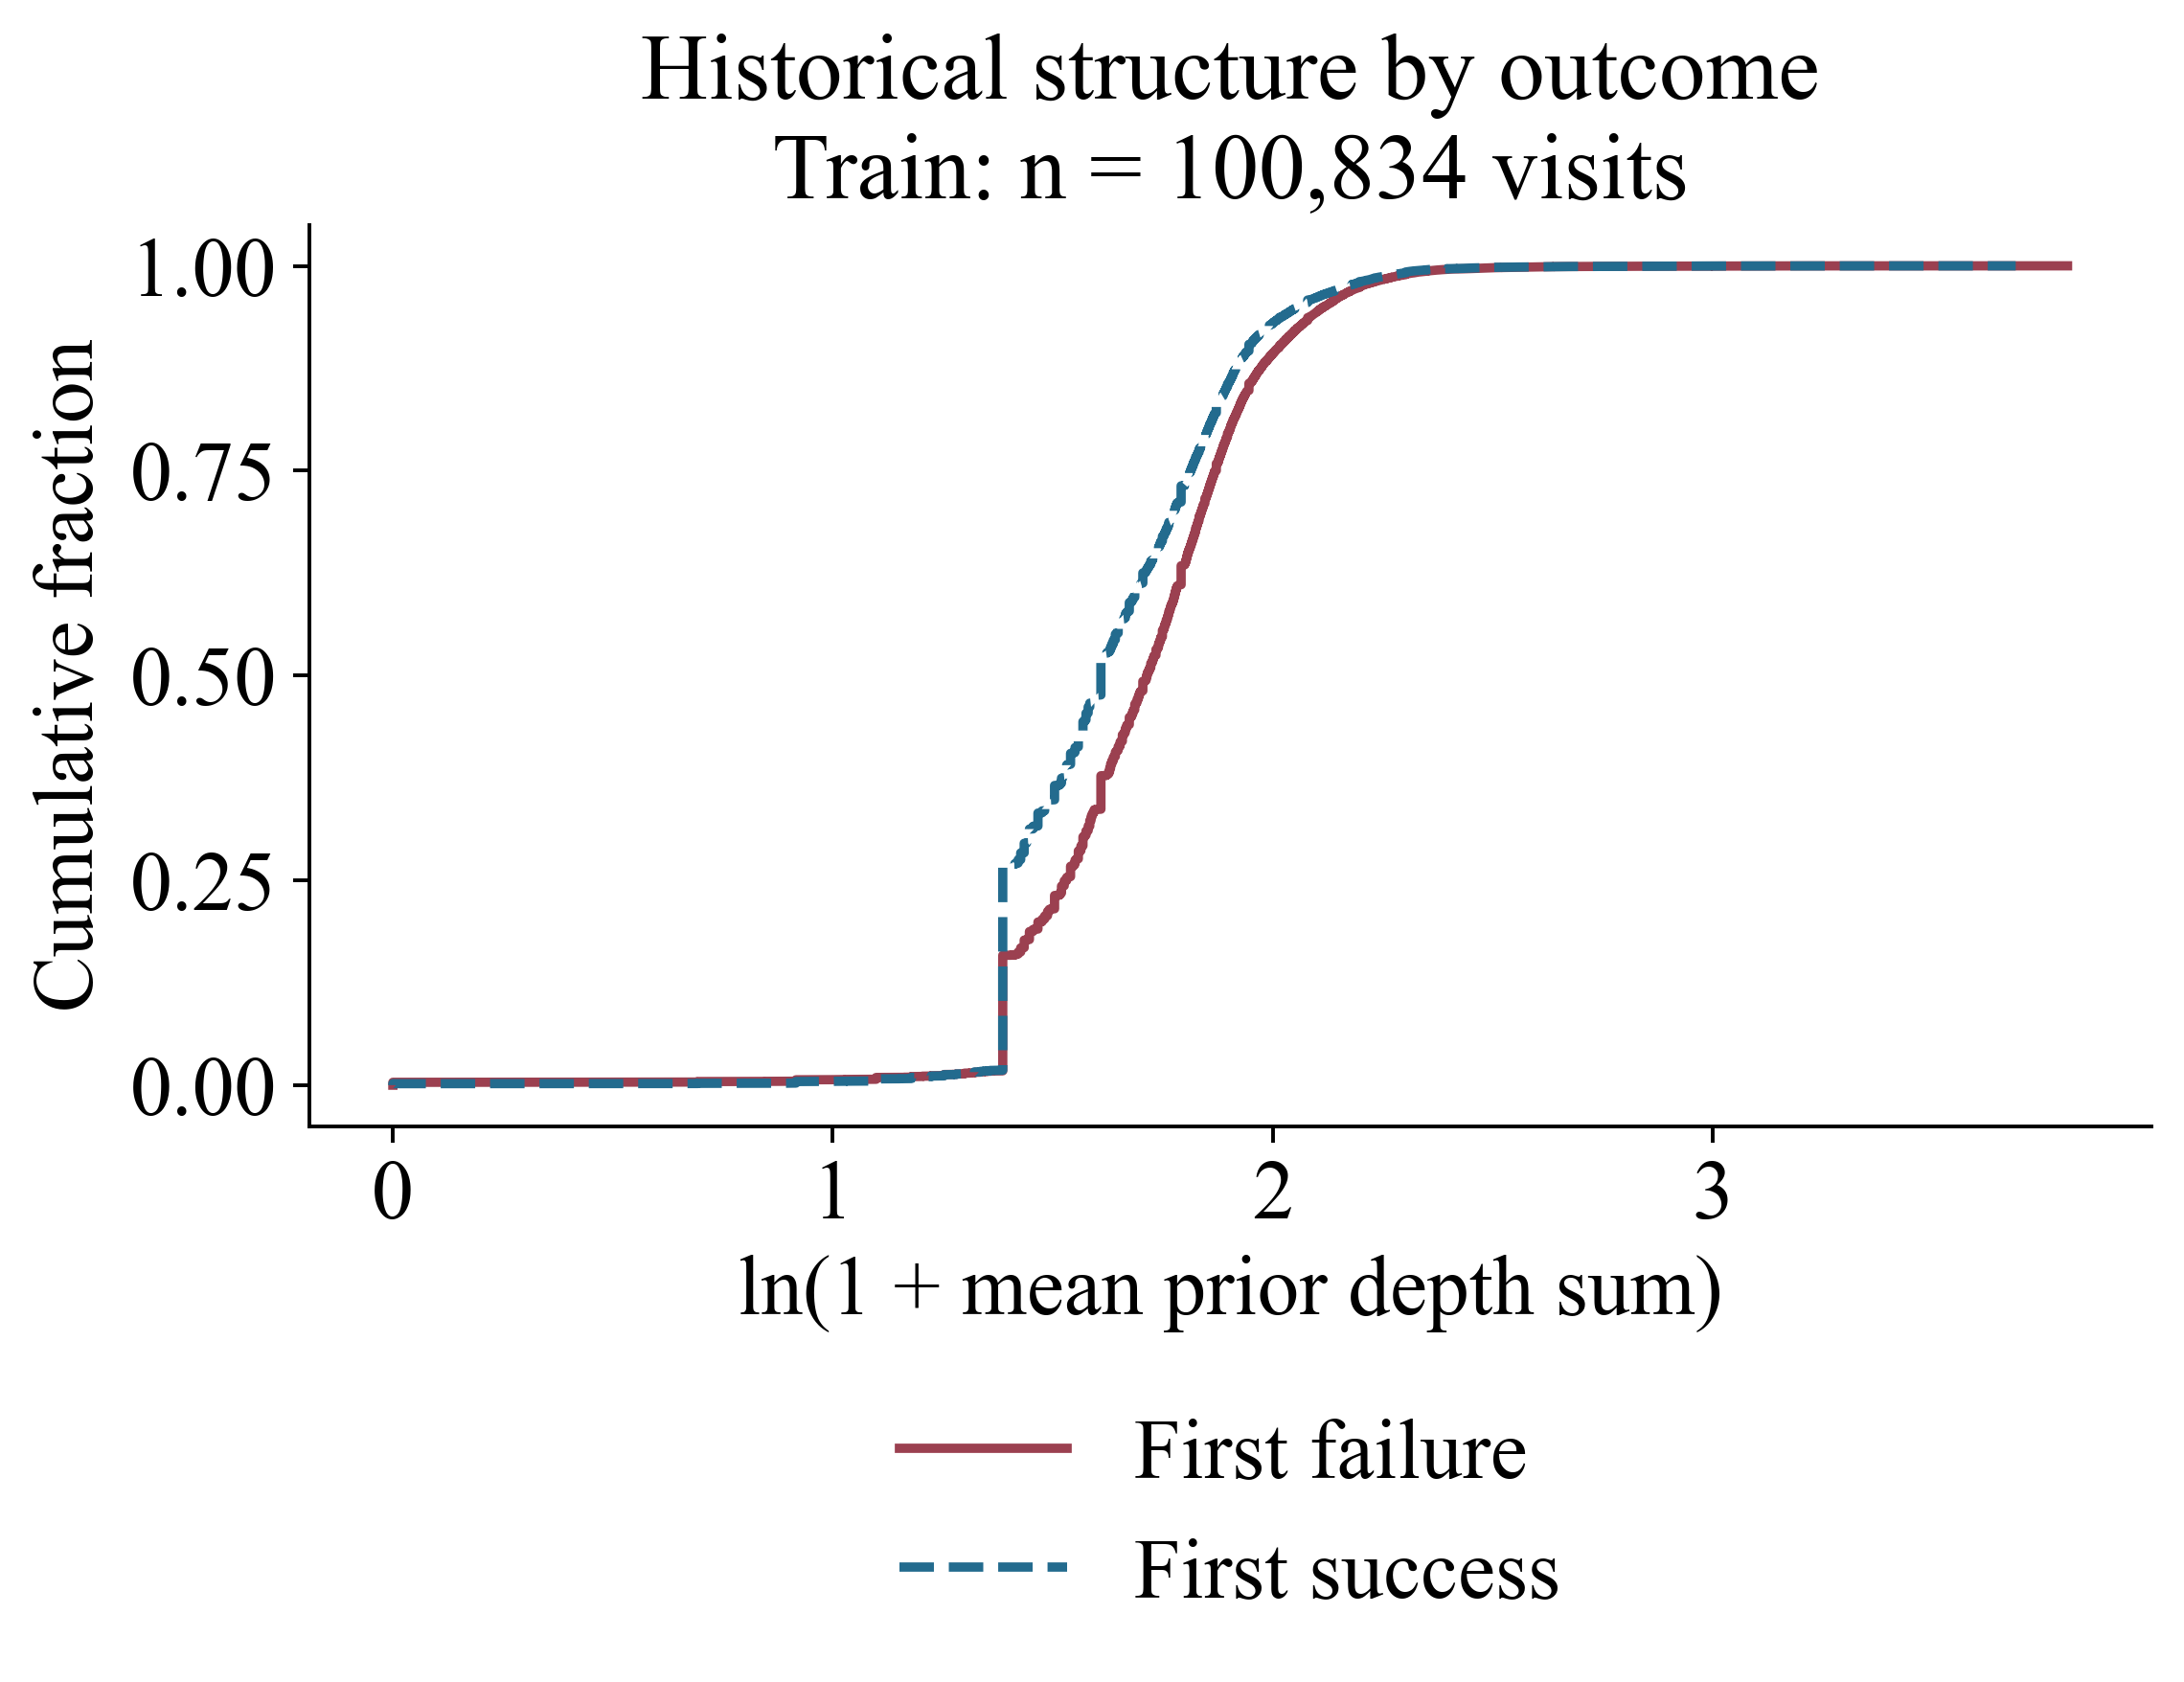

In [20]:
structure_source = tr.loc[
    tr.hist_code_depth_sum.notna(), ["student", "y", "hist_code_depth_sum"]
].copy()
structure_source["log_depth_sum"] = np.log1p(
    structure_source.hist_code_depth_sum
)
structure_source.to_csv(
    ROOT / "artifacts/02_structure_outcome_source.csv", index=False
)
fig, ax = plt.subplots(figsize=(6.4, 4.9), layout="constrained")
for outcome, color, linestyle in [(0, "#9B4050", "-"), (1, "#236B8E", "--")]:
    values = np.sort(
        structure_source.loc[
            structure_source.y.eq(outcome), "log_depth_sum"
        ].to_numpy()
    )
    ax.plot(
        values,
        np.arange(1, len(values) + 1) / len(values),
        color=color,
        linestyle=linestyle,
        linewidth=2,
        label="First failure" if outcome == 0 else "First success",
    )
ax.set(
    xlabel="ln(1 + mean prior depth sum)",
    ylabel="Cumulative fraction",
    title=f"Historical structure by outcome\nTrain: n = {len(structure_source):,} visits",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "02_structure_by_outcome")
plt.show()


Распределение предшествующей глубины кода при первом неуспехе сдвинуто вправо, но кривые сильно перекрываются. Это совместимо с переходом к более сложным заданиям и не доказывает отрицательного влияния сложного кода. Отдельный структурный признак не разделяет исходы однозначно.

## Неоднородность заданий внутри учебных разделов

Достаточно ли номера раздела для описания трудности? Каждая точка — задание train; её положение показывает наблюдаемую долю первого успеха, а размер — число посещений. Между заданиями не предполагается случайное назначение учащихся.

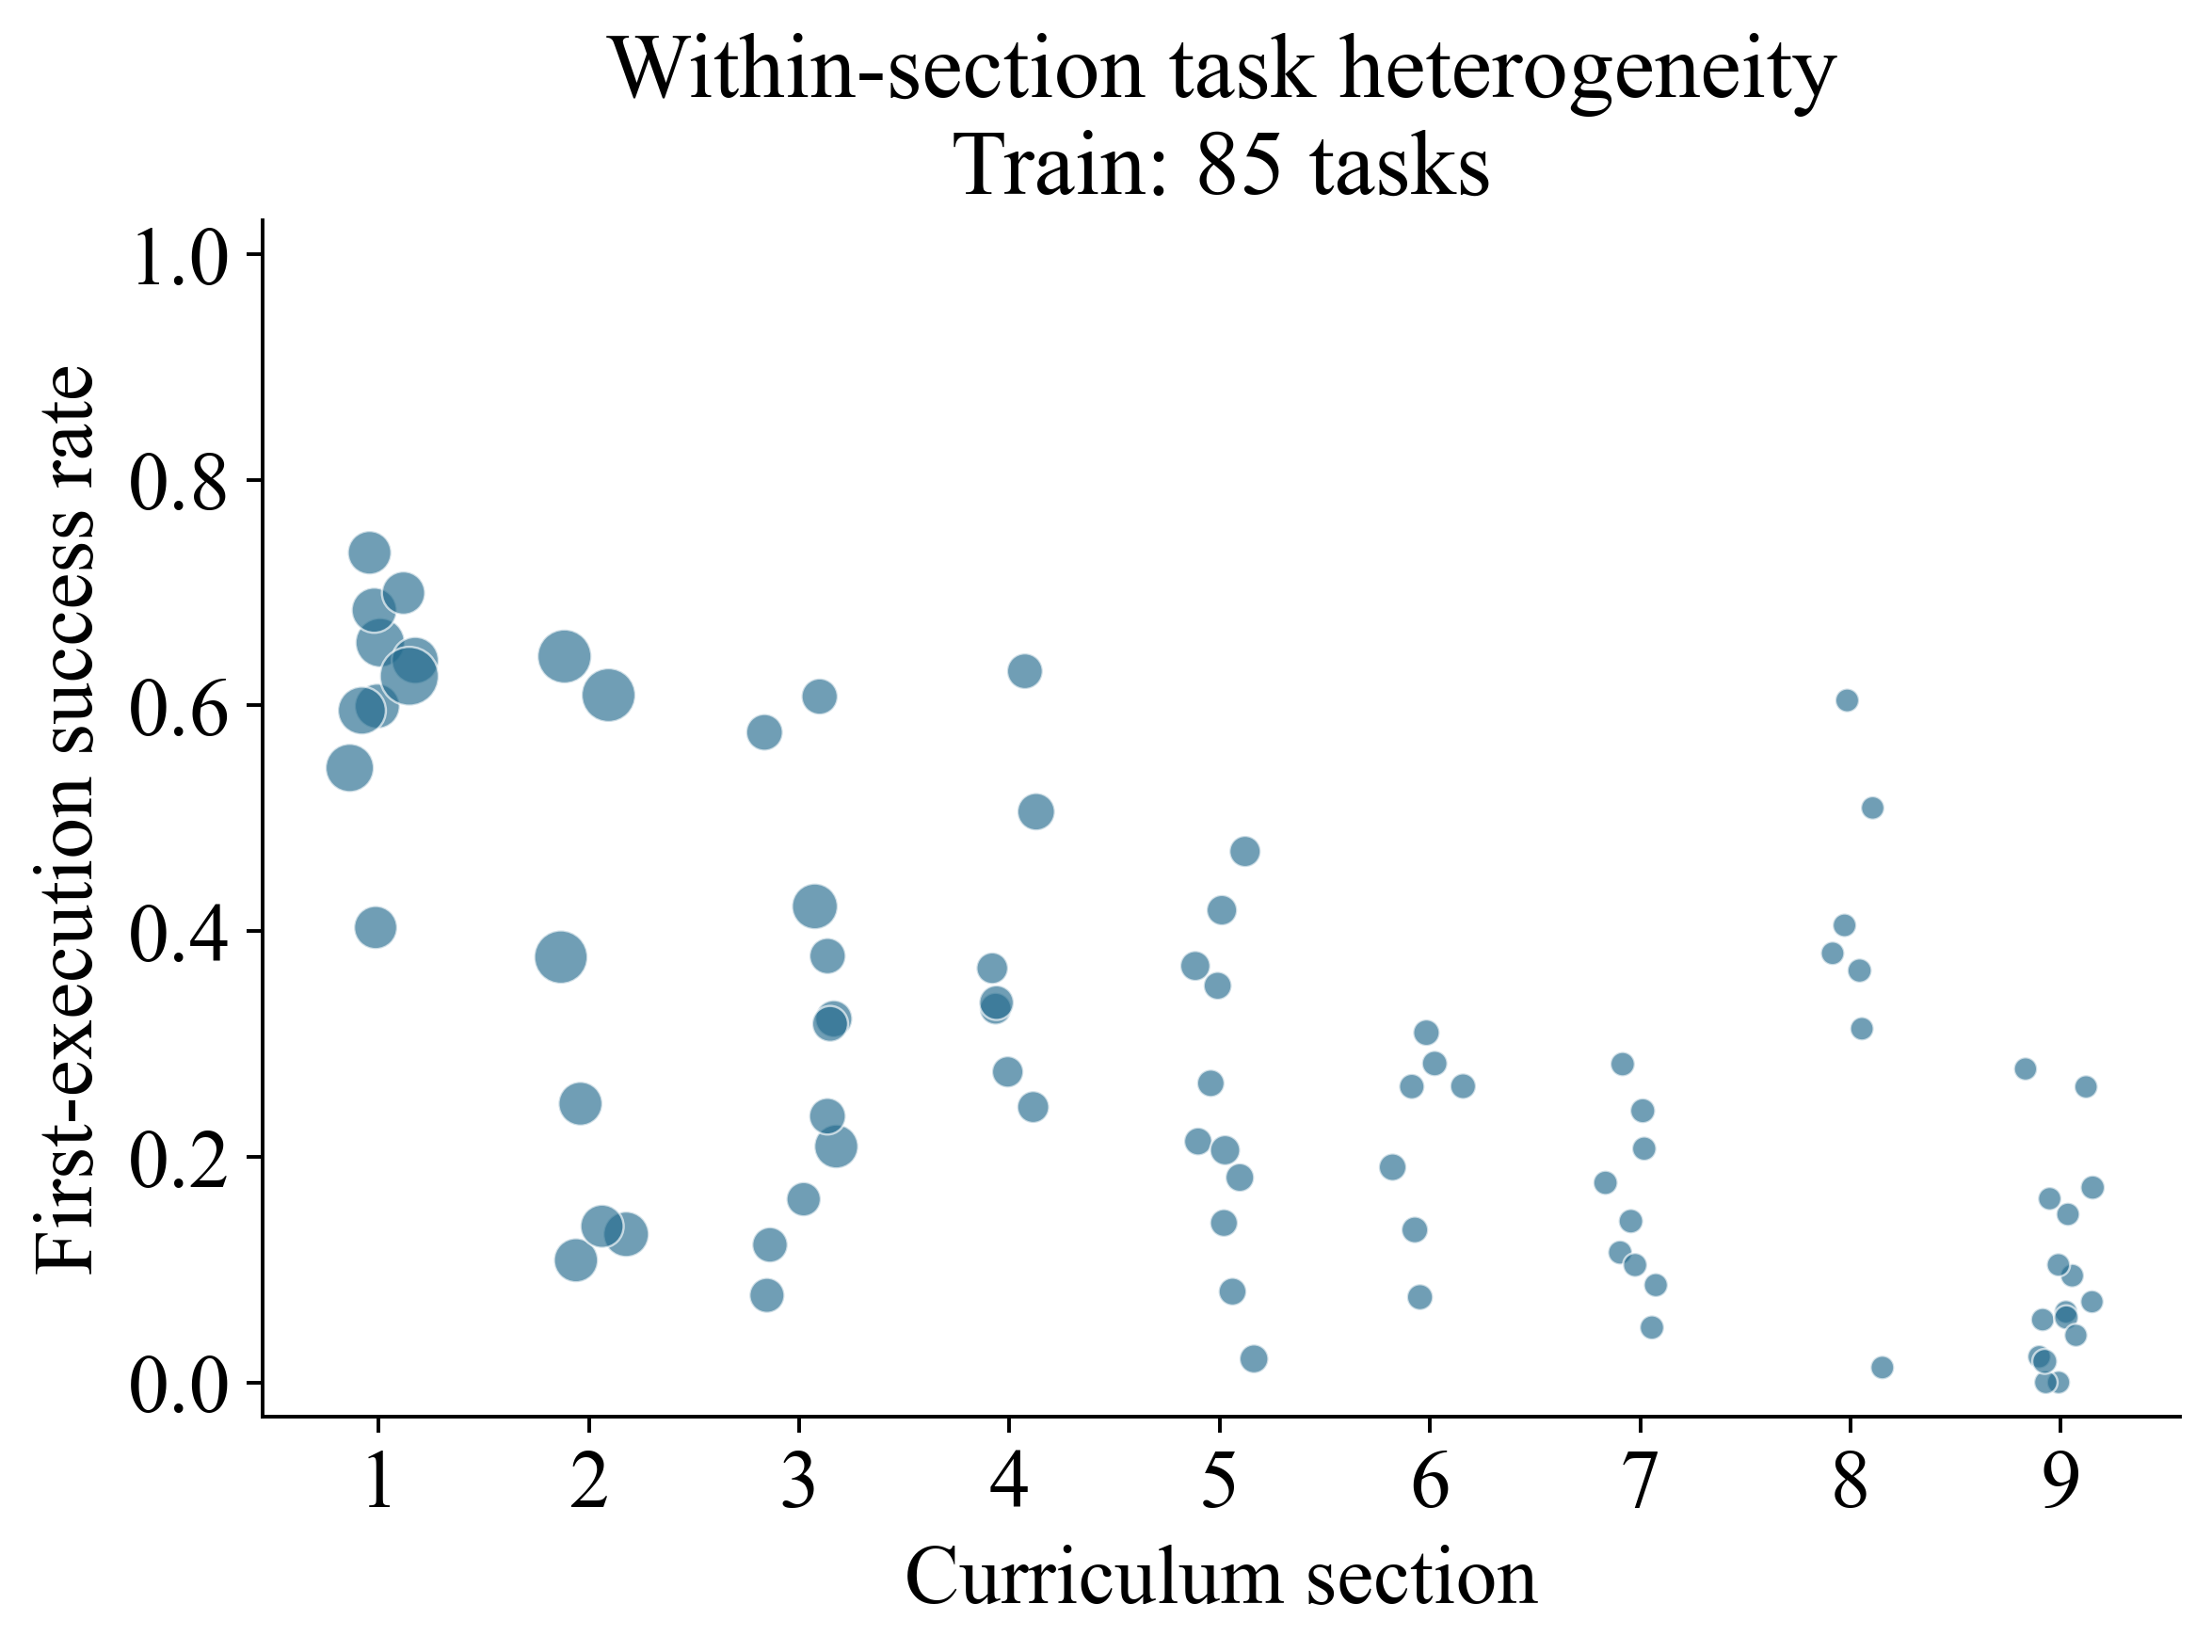

In [21]:
task_behavior = (
    tr.groupby("problem")
    .agg(
        n=("y", "size"), success_rate=("y", "mean"), level=("q_level", "first")
    )
    .reset_index()
)
task_behavior.to_csv(ROOT / "artifacts/02_task_heterogeneity.csv", index=False)
fig, ax = plt.subplots(figsize=(6.6, 4.9), layout="constrained")
positions = task_behavior.level + np.random.default_rng(SEED).uniform(
    -0.18, 0.18, len(task_behavior)
)
ax.scatter(
    positions,
    task_behavior.success_rate,
    s=25 + 140 * task_behavior.n / task_behavior.n.max(),
    color="#236B8E",
    alpha=0.65,
    edgecolor="white",
    linewidth=0.5,
)
ax.set(
    xlabel="Curriculum section",
    ylabel="First-execution success rate",
    title=f"Within-section task heterogeneity\nTrain: {len(task_behavior)} tasks",
    xticks=sorted(task_behavior.level.unique()),
    ylim=(-0.03, 1.03),
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "02_task_heterogeneity")
plt.show()


Внутри одного раздела доли первого успеха заметно различаются. Номер раздела не заменяет идентичность и описание задания. Размер точек отражает неодинаковую представленность; редкие задания требуют осторожной интерпретации.

## Школьная ветвь: совместное отсутствие сведений учителя

В каких классах отсутствует контекст учителя? Полотно показывает совместную структуру 16 показателей. Пропуски не удаляются; такая структура требует fold-local импутации с индикаторами доступности. Школьные результаты не смешиваются с RoboMission.

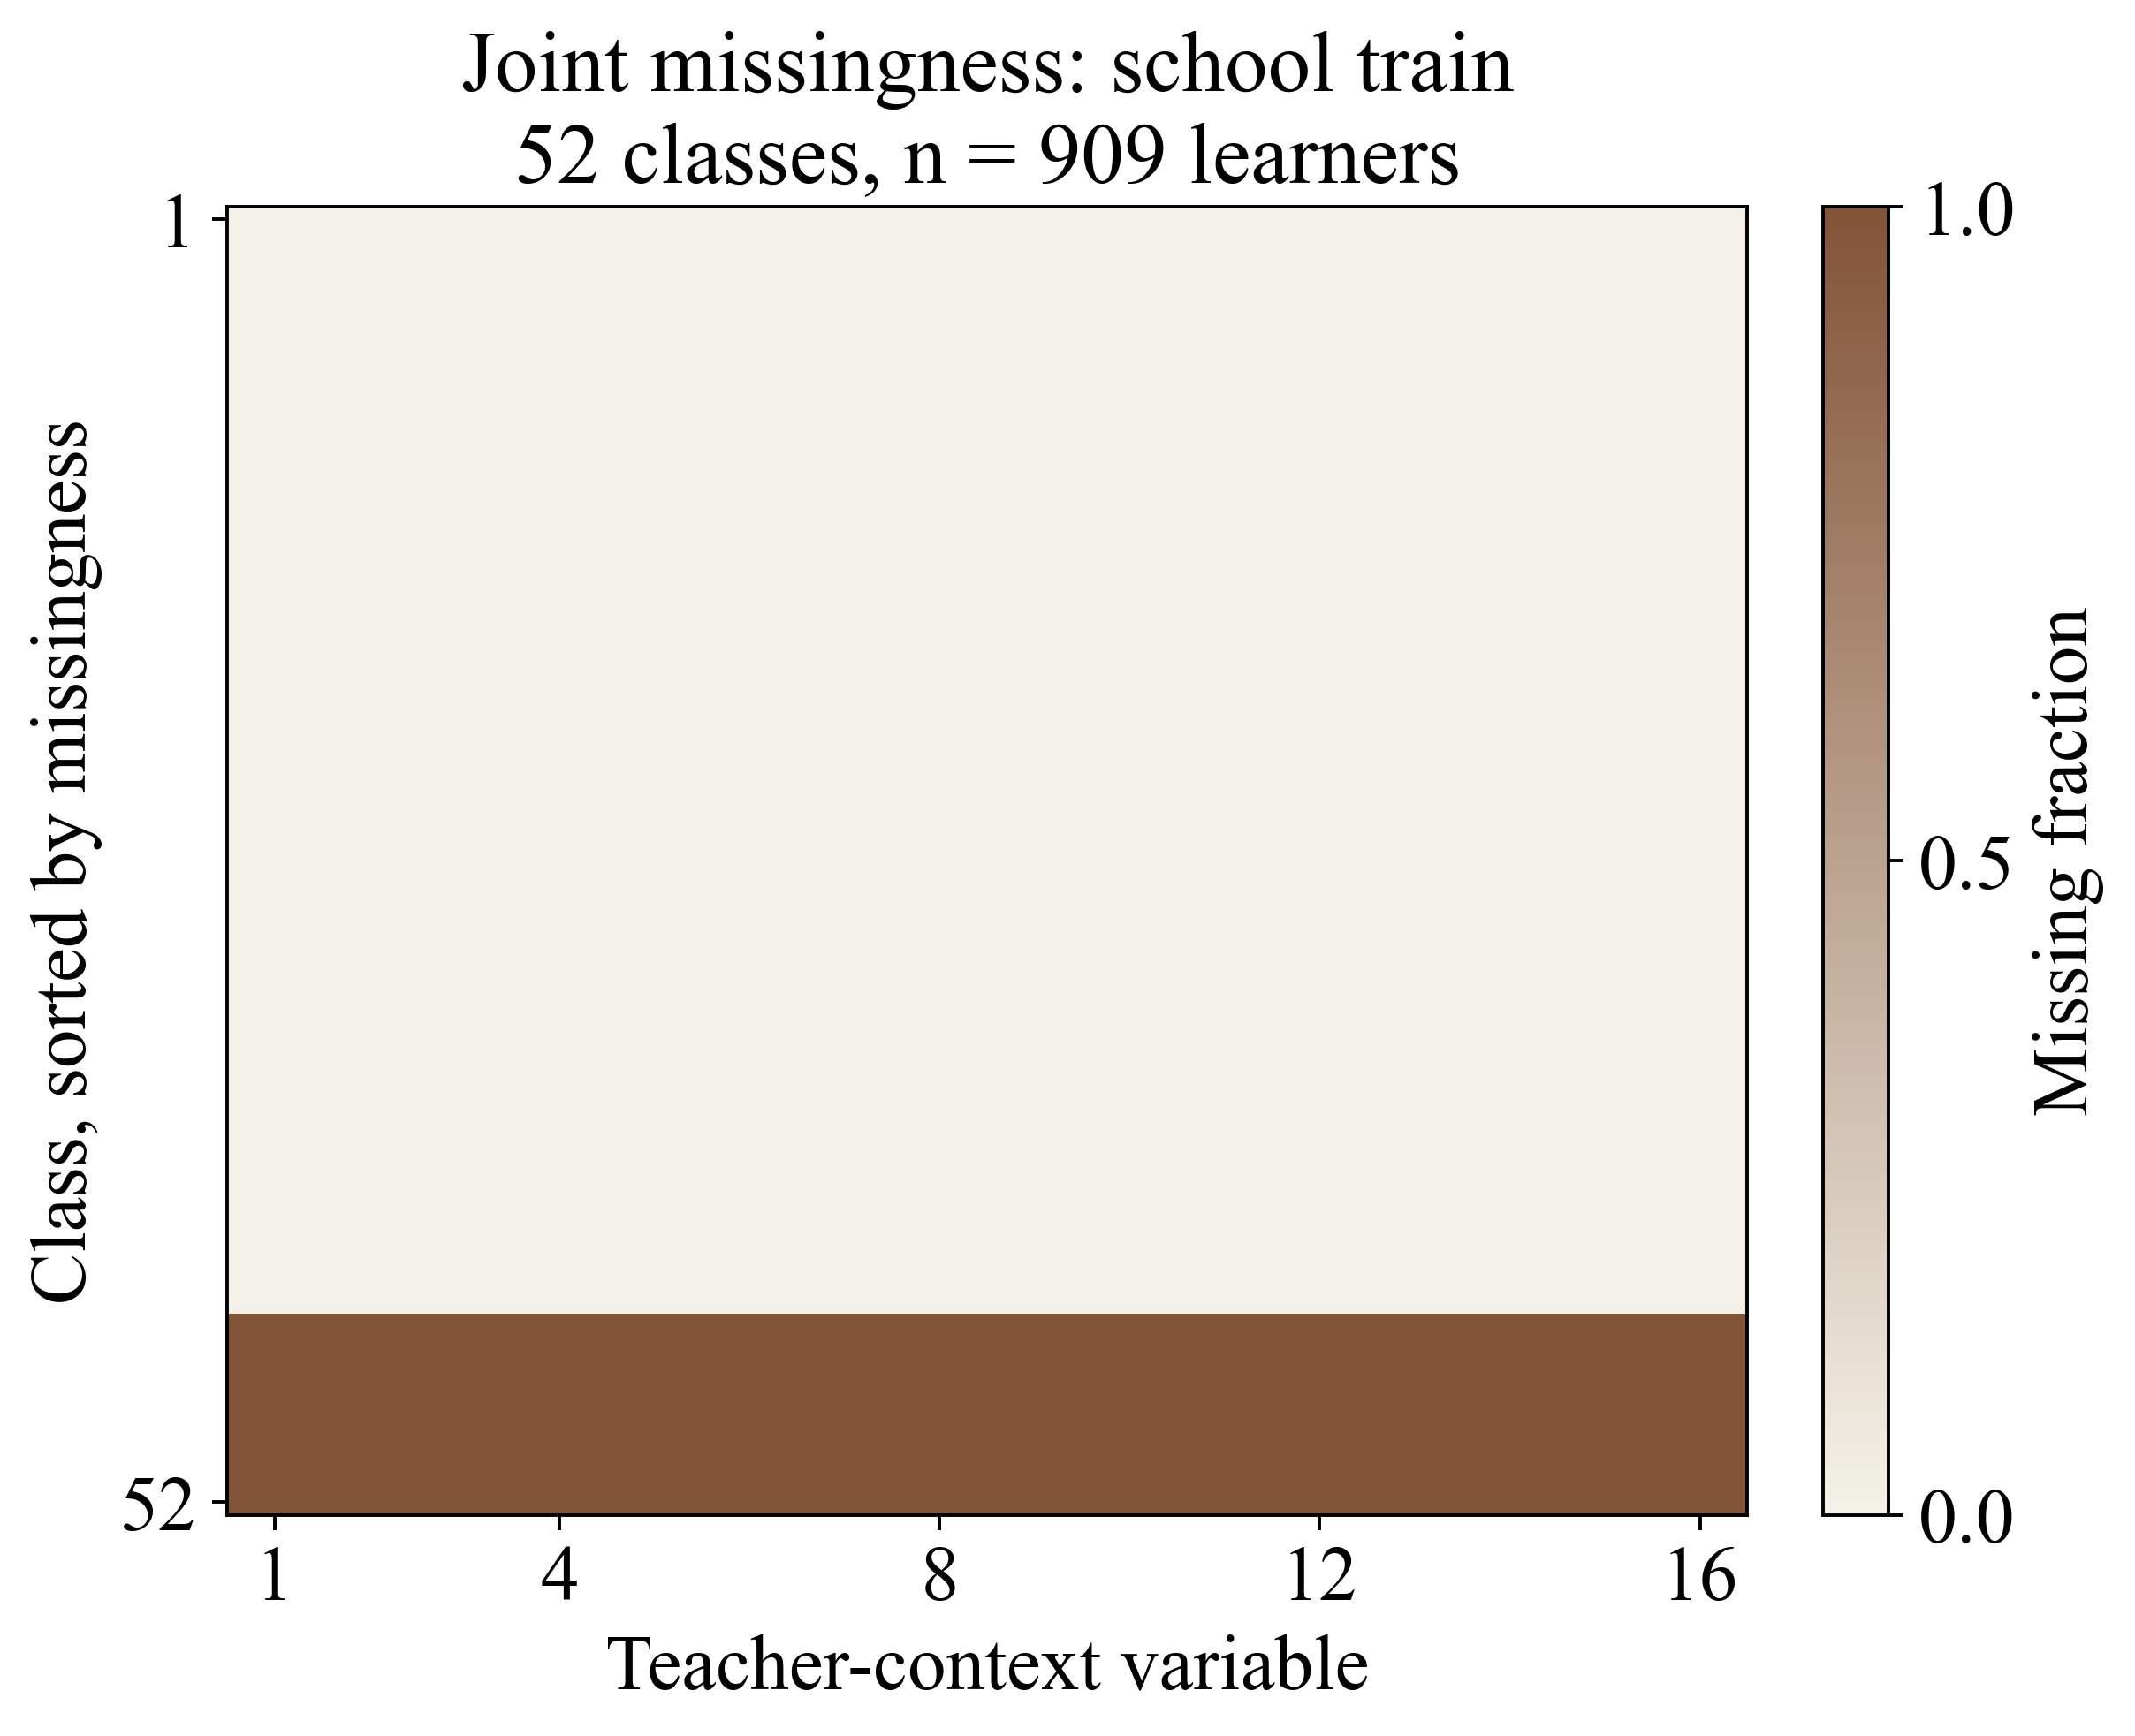

In [22]:
school_training = pd.read_pickle(ROOT / "dataset/processed/school_train.pkl")
school_contract = json.loads(
    (ROOT / "dataset/protocol/school_features.json").read_text()
)
teacher_features = school_contract["teacher_features"]
class_missing = school_training.groupby("class_group")[teacher_features].agg(
    lambda s: s.isna().mean()
)
class_missing = class_missing.loc[
    class_missing.mean(axis=1).sort_values().index
]
class_missing.to_csv(ROOT / "artifacts/02_school_missing_patterns.csv")
fig, ax = plt.subplots(figsize=(6.8, 5.5), layout="constrained")
artist = ax.imshow(
    class_missing.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    cmap=LinearSegmentedColormap.from_list(
        "alpha_missing", ["#F4F2E8", "#825337"]
    ),
    vmin=0,
    vmax=1,
)
ax.set_xticks([0, 3, 7, 11, 15], ["1", "4", "8", "12", "16"])
ax.set_yticks([0, len(class_missing) - 1], ["1", str(len(class_missing))])
ax.set(
    xlabel="Teacher-context variable",
    ylabel="Class, sorted by missingness",
    title=f"Joint missingness: school train\n{len(class_missing)} classes, n = {len(school_training)} learners",
)
fig.colorbar(artist, ax=ax, ticks=[0, 0.5, 1], label="Missing fraction")
save_figure(fig, "02_school_missing_patterns")
plt.show()


Пропуски контекста учителя образуют совместные блоки по классам, а не отдельные случайные клетки. Это поддерживает импутацию с индикаторами пропусков и проверку переносимости между школами. Классы отсортированы только для отображения; порядок не является временной шкалой.

## Передача к обучению

Входы строятся из доступной истории и условий следующего задания. Графы программ и последовательности сохраняются для сравнения табличных и последовательных моделей. Дополнительная задача имеет индикатор наблюдаемого успеха и учитывает цензурирование.

Корреляции, информация и нелинейная предсказуемость описывают разные свойства данных. Они не подтверждают педагогический эффект, истинные уровни компетенций или превосходство новой архитектуры.